## Readme
- 该版本在基础模型上增加了基于傅里叶遍历度量的条件引导
- 如果只是载入模型而不需要训练的情况下，直接执行Cell01-07+Cell10-11及其后面Cell12-14的可视化（可选）；即跳过Cell08-09.

## Cell 01 — 配置与设备/随机种子

In [ ]:
# Cell 01: Config + device + seed (standalone)

import os, yaml, random
from types import SimpleNamespace
from pathlib import Path
import numpy as np
import torch

def to_ns(d):
    if isinstance(d, dict): return SimpleNamespace(**{k: to_ns(v) for k,v in d.items()})
    if isinstance(d, list): return [to_ns(x) for x in d]
    return d

def load_config(path="config/config_ergodic.yaml"):
    cfg = None
    p = Path(path)
    if p.exists():
        with open(p, "r") as f:
            cfg = yaml.safe_load(f)
    else:
        # Fallback 默认配置（独立运行）
        cfg = {
            "data": {
                "data_dir": "data/ergodic_dataset",   # 相对当前notebook目录
                "trajectory_len": 101,
                "robot_state_dim": 4,
                "distribution_dim": [32,32],
                "validation_split": 0.1,
                "num_workers": 0,
                "shuffle_dataset": True,
                "seed": 42
            },
            "training": {
                "batch_size": 64,
                "device": "cuda",
                "seed": 42
            },
            "diffusion": {
                "beta_min": 0.1,
                "beta_max": 20.0,
                "steps": 100
            },
            "normalizer": {
                "robot_state": {"mean": [0.0,0.0,0.0,0.0], "std": [1.0,1.0,1.0,1.0]}
            }
        }
    cfg = to_ns(cfg)

    # 兼容顶层常用字段
    cfg.data_dir = cfg.data.data_dir
    cfg.trajectory_len = cfg.data.trajectory_len
    cfg.robot_state_dim = cfg.data.robot_state_dim
    cfg.distribution_dim = cfg.data.distribution_dim

    # 规范化 mean/std 为 tensor
    mean = torch.as_tensor(cfg.normalizer.robot_state.mean, dtype=torch.float32)
    std  = torch.as_tensor(cfg.normalizer.robot_state.std,  dtype=torch.float32)
    std  = torch.where(std==0, torch.tensor(1.0), std)
    cfg.normalizer.robot_state.mean = mean
    cfg.normalizer.robot_state.std  = std
    return cfg

config = load_config()  # 如需自定义，改这里路径
device = torch.device(config.training.device if torch.cuda.is_available() else "cpu")

# 采样期能量引导参数（紧跟在 config = load_config() 之后）
if not hasattr(config, "sampling"):
    class _S: pass
    config.sampling = _S()
config.sampling.use_energy_guidance = True
config.sampling.fourier_Kx = 8
config.sampling.fourier_Ky = 8
config.sampling.time_discount_alpha = 2.0
config.sampling.eta_base = 0.2         # 0.1–0.3 可调
config.sampling.erg_budget = None      # 先不设预算
config.sampling.erg_gate_tau = 0.05
config.sampling.guide_scale = 1.0
print("sampling cfg:",
      {k: getattr(config.sampling, k) for k in
       ["use_energy_guidance","fourier_Kx","fourier_Ky","eta_base","erg_budget"]})

# 随机种子
seed = int(getattr(config.training, "seed", 42))
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

print("Device:", device)
print("Data dir:", config.data_dir)


## Cell 02 — 数据集与 DataLoader
获取训练/验证 DataLoader（Dataset 已含 padding）
-改动目标：新增一个 _pack_gaussian_params 方法。
-逻辑：设定一个最大组件数 N_MAX（例如 20）。将每个样本的 GMM 参数展平并填充到这个长度。同时返回一个 mask，告诉模型哪些是真实数据，哪些是填充的 0。

In [ ]:
# Cell 02: Data module (v3.5: Gamma Injection + Safe Gaussian Params)

import os, json, numpy as np, torch
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler

def as_tensor_f32(x):
    return x.to(torch.float32) if isinstance(x, torch.Tensor) else torch.as_tensor(x, dtype=torch.float32)

class ErgodicDataset(Dataset):
    def __init__(self, data_dir, transform=None, max_trajectory_len=101, use_index=True, max_gaussians=20):
        self.data_dir = data_dir
        self.transform = transform
        self.max_trajectory_len = max_trajectory_len
        self.max_gaussians = max_gaussians
        
        self.distributions_dir = os.path.join(data_dir, 'distributions')
        self.trajectories_dir  = os.path.join(data_dir, 'trajectories')
        self.data_pairs = []

        index_path = os.path.join(data_dir, 'dataset_index.json')
        
        index_loaded = False
        if use_index and os.path.exists(index_path):
            try:
                with open(index_path, 'r') as f:
                    loaded_data = json.load(f)
                if isinstance(loaded_data, list):
                    self.data_pairs = loaded_data
                    index_loaded = True
            except: pass
        
        if not index_loaded or len(self.data_pairs) == 0:
            self._build_index(index_path)
            
    def _build_index(self, index_path):
        self.data_pairs = [] 
        dist_files = [f for f in os.listdir(self.distributions_dir) if f.endswith('.json')]
        dist_id_to_file = {d: d for d in dist_files} # Simplified map
        # Build accurate map
        dist_id_to_file = {}
        for df in dist_files:
            try:
                with open(os.path.join(self.distributions_dir, df), 'r') as f:
                    d = json.load(f)
                dist_id_to_file[d['id']] = df
            except: pass

        for tf in os.listdir(self.trajectories_dir):
            if tf.endswith('.json'):
                try:
                    with open(os.path.join(self.trajectories_dir, tf), 'r') as f:
                        t = json.load(f)
                    did = t['distribution_id']
                    if did in dist_id_to_file:
                        self.data_pairs.append({
                            'distribution_file': dist_id_to_file[did],
                            'trajectory_file': tf
                        })
                except: pass
        try:
            with open(index_path, 'w') as f:
                json.dump(self.data_pairs, f)
        except: pass

    def __len__(self):
        return len(self.data_pairs)

    def _generate_distribution_grid(self, dist_data, grid_size=(32,32)):
        # (省略具体实现，保持原样以节省篇幅，请确保你保留了之前的实现)
        # ... 
        # 简写版占位，请用你之前的完整代码
        bounds = dist_data.get('bounds', [[0,3],[0,3]])
        centers = np.asarray(dist_data['params']['centers'])
        covs    = np.asarray(dist_data['params']['covs'])
        weights = np.asarray(dist_data['params']['weights'])
        n = int(dist_data['params']['n_gaussians'])
        x = np.linspace(bounds[0][0], bounds[0][1], grid_size[0])
        y = np.linspace(bounds[1][0], bounds[1][1], grid_size[1])
        X, Y = np.meshgrid(x, y)
        Z = np.zeros_like(X, dtype=np.float64)
        for i in range(n):
            cx, cy = centers[i]
            c = covs[i]
            if np.isscalar(c): sx, sy = c, c
            elif len(np.shape(c)) == 1: sx, sy = c[0], c[1]
            else: sx, sy = np.sqrt(np.diag(c))
            Z += weights[i] * np.exp(-(((X-cx)**2)/(2*sx**2 + 1e-8) + ((Y-cy)**2)/(2*sy**2 + 1e-8)))
        Z /= (Z.max() + 1e-8)
        return Z

    def _process_trajectory(self, traj_data):
        # (保持之前的实现，确保 controls 是全零)
        states = np.asarray(traj_data['states'], dtype=np.float64)
        pos = states[:, :2]
        vel = np.zeros((states.shape[0],1))
        if states.shape[1] > 3: vel = states[:, 3:4]
        elif states.shape[0] > 1: 
            dt = float(traj_data['time_step'])
            d = np.linalg.norm(np.diff(pos, axis=0), axis=1)
            vel = np.vstack([np.zeros((1,1)), (d/dt)[:,None]])
        heading = states[:, 2:3] if states.shape[1] > 2 else np.zeros((states.shape[0],1))
        rs = np.hstack([pos, heading, vel])
        
        T = self.max_trajectory_len
        controls = np.zeros((T, 2), dtype=np.float32) # 强制全零
        
        if len(rs) > T:
            idx = np.linspace(0, len(rs)-1, T).astype(int)
            rs = rs[idx]
        elif len(rs) < T:
            pad = T - len(rs)
            rs = np.vstack([rs, np.zeros((pad, rs.shape[1]))])
            
        return rs, controls, float(traj_data['time_step']), float(traj_data['total_time']), float(traj_data['ergodic_metric']), float(traj_data['gamma'])

    def _pack_gaussian_params(self, dist_data):
        # (保持之前的实现)
        n = int(dist_data['params']['n_gaussians'])
        centers = np.asarray(dist_data['params']['centers'])
        weights = np.asarray(dist_data['params']['weights'])
        covs_raw = dist_data['params']['covs']
        packed = np.zeros((self.max_gaussians, 7), dtype=np.float32)
        mask = np.zeros((self.max_gaussians), dtype=bool)
        mask[n:] = True
        for i in range(min(n, self.max_gaussians)):
            packed[i, 0:2] = centers[i]
            c = covs_raw[i]
            if np.isscalar(c): cov_mat = np.array([c, 0, 0, c])
            elif len(np.shape(c)) == 1: cov_mat = np.array([c[0], 0, 0, c[1]])
            else: cov_mat = np.asarray(c).flatten()
            if cov_mat.size == 4: packed[i, 2:6] = cov_mat
            packed[i, 6] = weights[i]
        return packed, mask

    def __getitem__(self, idx):
        pair = self.data_pairs[idx]
        with open(os.path.join(self.distributions_dir, pair['distribution_file']), 'r') as f:
            dist_data = json.load(f)
        with open(os.path.join(self.trajectories_dir, pair['trajectory_file']), 'r') as f:
            traj_data = json.load(f)

        distribution_grid = self._generate_distribution_grid(dist_data) 
        rs, controls, time_step, total_time, ergodic_metric, gamma = self._process_trajectory(traj_data)
        gmm_packed, gmm_padding_mask = self._pack_gaussian_params(dist_data)
        
        # --- 核心修复：使用 Padded 数据填充 gaussian_params ---
        # 这样即使原始数据变长，传给 DataLoader 的也是定长 Tensor
        centers_padded = as_tensor_f32(gmm_packed[:, 0:2]) 
        covs_padded    = as_tensor_f32(gmm_packed[:, 2:6])
        weights_padded = as_tensor_f32(gmm_packed[:, 6])
        n_gauss = int(dist_data['params']['n_gaussians'])
        
        sample = {
            "distribution": as_tensor_f32(distribution_grid).unsqueeze(0), 
            "robot_state": as_tensor_f32(rs[0]),
            "trajectories": as_tensor_f32(rs),
            "controls": as_tensor_f32(controls),
            "gamma": as_tensor_f32(gamma).view(1), # Gamma 注入
            
            "gaussian_packed": as_tensor_f32(gmm_packed),        
            "gaussian_padding_mask": torch.tensor(gmm_padding_mask, dtype=torch.bool), 
            
            # 这里的修改消除了 [5,2] vs [7,2] 的冲突
            "gaussian_params": {
                "n_gaussians": torch.tensor(n_gauss, dtype=torch.long), 
                "centers": centers_padded, # [20, 2]
                "covs": covs_padded,       # [20, 4]
                "weights": weights_padded  # [20]
            }
        }
        return sample

def build_loaders(data_dir, batch_size=64, max_trajectory_len=101, val_split=0.1, num_workers=0, seed=42, transform=None):
    ds = ErgodicDataset(data_dir=data_dir, transform=transform, max_trajectory_len=max_trajectory_len)
    N = len(ds); idx = list(range(N))
    split = int(np.floor(val_split * N))
    rng = np.random.RandomState(seed); rng.shuffle(idx)
    val_idx, train_idx = idx[:split], idx[split:]
    train_loader = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(train_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    val_loader   = DataLoader(ds, batch_size=batch_size, sampler=SubsetRandomSampler(val_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    return train_loader, val_loader

print("ErgodicDataset ready (v3.5: Gamma + Safe Gaussian Params).")

## Cell 03 —  SDE 与训练/评估通用工具

In [ ]:
# Cell 03: VPSDE_linear + training utilities

import math
import torch
import torch.nn as nn

class VPSDE_linear:
    def __init__(self, beta_min=0.1, beta_max=20.0):
        self._beta_min = float(beta_min)
        self._beta_max = float(beta_max)
    @property
    def T(self): return 1.0
    def marginal_prob(self, x, t):
        # x_t = exp(mean_log_coeff)*x0 + std*z
        shape = x.shape
        t = t.view(-1, *([1]*(len(shape)-1)))
        mlc = -0.25 * t**2 * (self._beta_max - self._beta_min) - 0.5*self._beta_min*t
        mean = torch.exp(mlc) * x
        std  = torch.sqrt(torch.clamp(1 - torch.exp(2*mlc), min=1e-6))
        return mean, std

def time_weighted_masked_mse(pred, target, gamma=4.0, eps=1e-8):
    # pred/target: [B,T,D]；仅有效时刻参与；末段权重大
    B,T,D = target.shape
    mask = (target.abs().sum(dim=-1) > eps).float()            # [B,T]
    t = torch.arange(T, device=target.device).float().view(1,T)
    w = (t / max(T-1,1))**gamma
    w = (w*mask); w = w/(w.sum(dim=1, keepdim=True)+eps)
    diff2 = ((pred-target)**2).sum(dim=-1)
    return (((diff2*w).sum(dim=1)).mean())/D

def last_valid_idx_xy(xy, eps=1e-8):
    # xy: [B,T,2] or [T,2]
    if xy.ndim == 2:
        valid = ~(xy.abs().sum(dim=-1) <= eps)
        k = torch.nonzero(valid)[-1].item() if valid.any() else xy.shape[0]-1
        return k
    valid = ~(xy.abs().sum(dim=-1) <= eps)                     # [B,T]
    idx = []
    for b in range(xy.shape[0]):
        v = valid[b]; k = torch.nonzero(v)[-1].item() if v.any() else xy.shape[1]-1
        idx.append(k)
    return torch.tensor(idx, device=xy.device, dtype=torch.long)


## Cell 04 — Encoder
-架构：
1.GMM Embedding: 用 MLP 将 [7] 维的 GMM 参数映射到 hidden_dim。
2.Robot Embedding: 用 MLP 将 [4] 维的机器人状态映射到 hidden_dim。
3.序列拼接: 将 [Robot_Token, GMM_Token_1, ..., GMM_Token_N] 拼成序列。
4.Transformer Encoder: 处理序列。关键点：不加位置编码 (Positional Encoding)，因为 GMM 组件是无序的集合（Set），这保证了置换不变性。
5.输出：取第 0 个 Token（Robot Token）的输出作为全局上下文 encoding。

In [ ]:
# Cell 04: ErgodicEncoder (v4: Transformer with Gamma Conditioning)

import torch
import torch.nn as nn

class ErgodicEncoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.hidden_dim = int(getattr(cfg, 'hidden_dim', getattr(getattr(cfg,'model',object()),'hidden_dim',192)))
        state_dim = int(cfg.robot_state_dim)
        gmm_input_dim = 7
        
        # 1. Embeddings
        self.gmm_embedder = nn.Sequential(
            nn.Linear(gmm_input_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        
        self.robot_embedder = nn.Sequential(
            nn.Linear(state_dim, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        
        # --- 新增：Gamma Embedder ---
        # 输入是 [B, 1] 的标量
        self.gamma_embedder = nn.Sequential(
            nn.Linear(1, self.hidden_dim),
            nn.GELU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.LayerNorm(self.hidden_dim)
        )
        # ---------------------------
        
        # 2. Transformer Encoder (保持不变)
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.hidden_dim, nhead=4, dim_feedforward=512, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.final_ln = nn.LayerNorm(self.hidden_dim)

    def forward(self, inputs):
        """
        inputs 需包含: 'robot_state', 'gaussian_packed', 'gaussian_padding_mask', 'gamma'
        """
        rs = inputs['robot_state']             # [B, 4]
        gmm_tokens = inputs['gaussian_packed'] # [B, N, 7]
        padding_mask = inputs['gaussian_padding_mask'] # [B, N]
        gamma = inputs['gamma']                # [B, 1] <-- 新增
        
        B = rs.shape[0]
        
        # 1. Embeddings
        rs_emb = self.robot_embedder(rs).unsqueeze(1)      # [B, 1, H]
        gmm_emb = self.gmm_embedder(gmm_tokens)            # [B, N, H]
        gamma_emb = self.gamma_embedder(gamma).unsqueeze(1)# [B, 1, H] <-- 新增
        
        # 2. Concat: [Robot, Gamma, GMM_1...N]
        # 序列长度增加 1
        src = torch.cat([rs_emb, gamma_emb, gmm_emb], dim=1) # [B, 2+N, H]
        
        # 3. Prepare Mask
        # Robot(0) 和 Gamma(1) 都是永远有效的 (False)
        prefix_mask = torch.zeros((B, 2), device=src.device, dtype=torch.bool)
        src_key_padding_mask = torch.cat([prefix_mask, padding_mask], dim=1) # [B, 2+N]
        
        # 4. Transformer Pass
        output = self.transformer(src, src_key_padding_mask=src_key_padding_mask)
        
        # 5. Output
        # 我们依然返回完整序列，供 Decoder Cross-Attention 使用
        # 记得也要返回新的 mask
        return {
            "encoding": output, 
            "encoding_mask": src_key_padding_mask
        }

## Cell 05 — DiT/Decoder（仅采样器保留允许的导入）

In [ ]:
# Cell 05: ErgodicDecoder / DiT (Clean Version for Transformer & xt-Guidance)

import torch
import torch.nn as nn
import math
from timm.models.layers import Mlp
from models.diffusion_utils.sampling import dpm_sampler 

# --- 1. 基础组件 (保持不变) ---
class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.half = hidden_dim//2
        self.emb = nn.Linear(hidden_dim, hidden_dim)
    def forward(self, t):
        freqs = torch.exp(-math.log(10000)*torch.arange(0,self.half,device=t.device)/self.half)
        x = torch.cat([torch.cos(t[:,None]*freqs[None,:]),
                       torch.sin(t[:,None]*freqs[None,:])], dim=-1)
        return self.emb(x)

# Cell 05: DiTBlock (修正版)

class DiTBlock(nn.Module):
    def __init__(self, hidden_dim, heads, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_dim)
        # Self-Attention (SA)
        self.sa = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(hidden_dim)
        # Cross-Attention (CA)
        self.ca = nn.MultiheadAttention(hidden_dim, heads, dropout=dropout, batch_first=True)
        self.norm3 = nn.LayerNorm(hidden_dim)
        self.mlp = Mlp(in_features=hidden_dim, hidden_features=int(hidden_dim*4), act_layer=nn.GELU, drop=dropout)
        self.drop = nn.Dropout(dropout)
        
    def forward(self, x, context=None):
        # x 是轨迹 Token，形状 [B, H]
        
        # 1. Self-Attention (SA) - 轨迹 Token 自注意力
        # Query/Key/Value 都是 x 的 unsqueeze(1) 版本 [B, 1, H]
        h = self.norm1(x); h = self.sa(h.unsqueeze(1), h.unsqueeze(1), h.unsqueeze(1))[0].squeeze(1)
        x = x + self.drop(h)
        
        # 2. Cross-Attention (CA) - 轨迹 Token 查询 GMM 序列
        h = self.norm2(x); 
        
        # Query (h_q): 轨迹 Token, 形状 [B, 1, H]
        h_q = h.unsqueeze(1)
        
        # Key/Value (h_kv): GMM/Robot State 序列, 形状 [B, L_c, H]
        # --- 关键修正：移除 context 上的冗余 unsqueeze(1) ---
        h_kv = context 
        # ------------------------------------------------
        
        h = self.ca(h_q, h_kv, h_kv)[0].squeeze(1) # [B, 1, H] -> [B, H]
        
        x = x + self.drop(h)
        
        # 3. MLP
        h = self.norm3(x); h = self.mlp(h); x = x + self.drop(h)
        
        return x

class FinalLayer(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim)
        self.proj = nn.Linear(hidden_dim, output_dim)
    def forward(self, x, t_emb):
        return self.proj(self.norm(x))

class ErgodicDiT(nn.Module):
    def __init__(self, output_dim, hidden_dim, depth, heads, dropout=0.1, model_type="x_start"):
        super().__init__()
        self.output_dim = output_dim
        self.hidden_dim = hidden_dim
        self.model_type = model_type 
        self.traj_proj = nn.Sequential(
            nn.Linear(output_dim, hidden_dim * 2), nn.GELU(), nn.Linear(hidden_dim * 2, hidden_dim)
        )
        self.t_embedder = TimestepEmbedder(hidden_dim)
        self.blocks = nn.ModuleList([DiTBlock(hidden_dim, heads, dropout=dropout) for _ in range(depth)])
        self.final = FinalLayer(hidden_dim, output_dim)

    def forward(self, x, t, context, conditions=None):
        # 1. 注入起点硬约束 (训练时通常为 None，采样时由 dpm_sampler 传入)
        if isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
            B = x.shape[0]
            # 假设 conditions[0] 是 [B, D_robot]
            # x 是 [B, T*D]
            # 我们需要知道 D
            D = conditions[0].shape[-1]
            T = self.output_dim // D
            
            xv = x.view(B, T, D)
            # 替换起点
            xv[:, 0, :] = conditions[0].to(xv.device)
            # 展平回 x
            x = xv.view(B, self.output_dim)

        # 2. DiT 主体
        h = self.traj_proj(x)
        t_emb = self.t_embedder(t)
        h = h + t_emb
        for blk in self.blocks:
            h = blk(h, context)
        return self.final(h, t_emb)

# --- 2. 顶层 Decoder (修正版) ---
class ErgodicDecoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.T = int(getattr(config, 'trajectory_len', getattr(getattr(config,'data',object()), 'trajectory_len', 101)))
        self.D = int(getattr(config, 'robot_state_dim', getattr(getattr(config,'data',object()), 'robot_state_dim', 4)))
        
        hd = int(getattr(config, 'hidden_dim', getattr(getattr(config,'model',object()), 'hidden_dim', 192)))
        depth = int(getattr(config, 'decoder_depth', getattr(getattr(config,'model',object()), 'decoder_depth', 3)))
        heads = int(getattr(config, 'num_heads', getattr(getattr(config,'model',object()), 'num_heads', 6)))
        drop  = float(getattr(config, 'decoder_drop_path_rate', getattr(getattr(config,'model',object()), 'decoder_drop_path_rate', 0.1)))
        self.model_type = str(getattr(config, 'diffusion_model_type', getattr(getattr(config,'diffusion',object()), 'model_type', "x_start")))
        
        self.output_dim = self.T * self.D
        self.dit = ErgodicDiT(self.output_dim, hd, depth, heads, dropout=drop, model_type=self.model_type)

    def forward(self, x_t, t, context):
        """
        训练路径调用
        """
        B = x_t.shape[0]
        # --- 修正：展平输入 ---
        x_flat = x_t.view(B, -1)
        
        out_flat = self.dit(x_flat, t, context, conditions=None)
        
        # --- 修正：恢复形状 ---
        return out_flat.view(B, self.T, self.D)

    @torch.no_grad()
    def inference(self, enc_out, inputs, steps=None, **kwargs):
        # ... (inference 代码保持不变，因为它内部已经处理了 view) ...
        enc = enc_out['encoding']; B = enc.shape[0]
        x_T = torch.randn(B, self.output_dim, device=enc.device)
        other = {"context": enc}
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            other["conditions"] = {0: inputs['robot_state']}
        if steps is None:
            steps = int(getattr(getattr(self.config, "diffusion", object()), "steps", 50))
        x0 = dpm_sampler(
            model=self.dit,
            x_T=x_T,
            other_model_params=other,
            diffusion_steps=steps,
            **kwargs 
        )
        traj = x0.view(B, self.T, self.D)
        if isinstance(inputs, dict) and inputs.get('robot_state') is not None:
            traj[:, 0, :] = inputs['robot_state']
        return {"prediction": traj}

如何彻底杜绝实例化仓库类（不使用别名）

思路：阻断和清空这几个仓库模块的导入，并在实例化前断言当前命名 ErgodicDiffusionModel 来自 Notebook（即 module == 'main'）。这既能清除已有绑定，又能防止后续误导入把名字重绑。
在你的 Notebook 中，添加并运行一个“导入隔离”单元（放在构建模型之前，建议贴近你定义完类的 Cell 06 后面）：

导入隔离与断言（一次性执行，之后实例化）

作用：从 sys.modules 清理仓库模型模块；拦截今后对这些模块的导入；并断言当前的 ErgodicDiffusionModel 来自 Notebook。
这不会引入别名，也不会影响你允许保留的 dpm_sampler 导入。


## Cell 05.5 — “Import quarantine”（导入隔离）

In [ ]:
# Import quarantine: block repo model modules; ensure we use the Notebook-defined class
import sys, builtins

# 需要屏蔽的仓库模块前缀（模型/编码器/解码器/主入口）
_BLOCK = (
    "diffusion_ergodic.models.diffusion_ergodic",
    "diffusion_ergodic.models.module.encoder",
    "diffusion_ergodic.models.module.decoder",
    "diffusion_ergodic.main",
)

# 1) 清理已加载的对应模块
for m in list(sys.modules.keys()):
    if any(m == b or m.startswith(b + ".") for b in _BLOCK):
        sys.modules.pop(m, None)

# 2) 打补丁：阻止后续再次导入这些仓库模块
if not hasattr(builtins, "_orig_import_guarded"):
    builtins._orig_import_guarded = builtins.__import__
    def _guarded_import(name, globals=None, locals=None, fromlist=(), level=0):
        if any(name == b or name.startswith(b + ".") for b in _BLOCK):
            raise ImportError(f"Blocked import of repo model module: {name}. Use the Notebook-defined class instead.")
        return builtins._orig_import_guarded(name, globals, locals, fromlist, level)
    builtins.__import__ = _guarded_import

# 3) 断言：当前命名绑定的是 Notebook 中定义的类
try:
    src_mod = ErgodicDiffusionModel.__module__
    assert src_mod == "__main__", f"ErgodicDiffusionModel is from {src_mod}, not Notebook. Re-run your class Cell 06 now."
    print("Guard OK: using Notebook-defined ErgodicDiffusionModel.")
except NameError:
    print("Define ErgodicDiffusionModel in this Notebook (Cell 06) before running the guard.")


## Cell 06 — 顶层模型（训练路径去噪；推理起点约束；默认损失）

In [ ]:
# Cell 06: Top-level Model (v5: Pass 'gamma' to Encoder)

import torch
import torch.nn as nn

class ErgodicDiffusionModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.encoder = ErgodicEncoder(config)
        self.sde = VPSDE_linear(
            beta_min=getattr(config.diffusion, 'beta_min', 0.1),
            beta_max=getattr(config.diffusion, 'beta_max', 20.0)
        )
        self.decoder = ErgodicDecoder(config)
        self.loss_fn = time_weighted_masked_mse 
        
        # 显式设置 loss_gamma 为 0.0 (Fix Lazy Loss)
        self.loss_gamma = float(getattr(config, 'loss_gamma', 0.0))
        
        self._last_loss_dict = {}

    def _build_enc_in(self, inputs):
        enc_in = {}
        # 基础字段
        if 'robot_state' in inputs: enc_in['robot_state'] = inputs['robot_state']
        if 'distribution' in inputs: enc_in['distribution'] = inputs['distribution']
        if 'gaussian_packed' in inputs: enc_in['gaussian_packed'] = inputs['gaussian_packed']
        if 'gaussian_padding_mask' in inputs: enc_in['gaussian_padding_mask'] = inputs['gaussian_padding_mask']
        
        # --- 关键修正：确保 Gamma 被透传到 Encoder ---
        if 'gamma' in inputs: enc_in['gamma'] = inputs['gamma']
        # ------------------------------------------
        
        return enc_in

    def forward(self, inputs, training=True):
        enc_in = self._build_enc_in(inputs)
        enc_out = self.encoder(enc_in)
        
        if training:
            x0 = inputs.get('trajectories')
            t = inputs.get('diffusion_time')
            if t is None:
                B = x0.shape[0]
                t = torch.rand(B, device=x0.device)
            mean, std = self.sde.marginal_prob(x0, t)
            z = torch.randn_like(x0)
            x_t = mean + std * z
            pred_x0 = self.decoder(x_t, t, context=enc_out['encoding'])
            return {"prediction": pred_x0, "target": x0}
        else:
            return {"encoding": enc_out['encoding']}

    def compute_loss(self, model_out, targets):
        pred = model_out["prediction"]
        # 使用 self.loss_gamma (0.0)
        loss = self.loss_fn(pred, targets, gamma=self.loss_gamma) 
        self._last_loss_dict = {"mse": loss.item()}
        return loss
        
    def get_loss_components(self):
        return self._last_loss_dict
        
    def inference(self, inputs):
        enc_in = self._build_enc_in(inputs)
        enc_out = self.encoder(enc_in)
        return self.decoder.inference(enc_out, inputs)

## Cell 07 — 训练与评估工具（最小版）
优化器/梯度裁剪；对齐“最后有效步”的评估指标；简洁打印。

In [ ]:
# 07 Rebuild DataLoaders (single-process) + Train/Eval utilities (Updated Data Path)

import os, time, math
import numpy as np
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler

# 0) 确保使用 Notebook 中定义的 Dataset/Model (省略 assert 语句)

# 1) 重建 DataLoader (build_loaders 函数定义不变)
def build_loaders(data_dir, batch_size=64, max_trajectory_len=101, val_split=0.1,
                  num_workers=0, seed=42, transform=None):
    ds = ErgodicDataset(data_dir=data_dir, transform=transform, max_trajectory_len=max_trajectory_len)
    N = len(ds); idx = list(range(N))
    split = int(np.floor(val_split * N))
    rng = np.random.RandomState(seed); rng.shuffle(idx)
    val_idx, train_idx = idx[:split], idx[split:]

    train_loader = DataLoader(ds, batch_size=batch_size,
                              sampler=SubsetRandomSampler(train_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    val_loader   = DataLoader(ds, batch_size=batch_size,
                              sampler=SubsetRandomSampler(val_idx),
                              num_workers=num_workers, pin_memory=True, drop_last=False)
    return train_loader, val_loader

def _get_cfg(path, default):
    return globals().get(path, default)

# --- 关键修改：修正 DATA_DIR 的默认值 ---
DATA_DIR   = _get_cfg("DATA_DIR",
                getattr(getattr(globals().get("config", object()), "data", object()), "data_dir",
                        "data/ergodic_dataset")) # <--- 修正：删除了 "diffusion_ergodic/" 前缀
# -----------------------------------

BATCH_SIZE = int(_get_cfg("BATCH_SIZE",
                getattr(getattr(globals().get("config", object()), "training", object()), "batch_size", 64)))
TRAJ_LEN   = int(_get_cfg("TRAJ_LEN",
                getattr(getattr(globals().get("config", object()), "data", object()), "trajectory_len", 101)))
VAL_SPLIT  = float(_get_cfg("VAL_SPLIT",
                getattr(getattr(globals().get("config", object()), "data", object()), "validation_split", 0.1)))
NUM_WORKERS= int(_get_cfg("NUM_WORKERS", 0)) 
SEED       = int(_get_cfg("SEED",
                getattr(getattr(globals().get("config", object()), "data", object()), "seed", 42)))
TRANSFORM  = _get_cfg("TRANSFORM", None)

train_loader, val_loader = build_loaders(
    data_dir=DATA_DIR, batch_size=BATCH_SIZE, max_trajectory_len=TRAJ_LEN,
    val_split=VAL_SPLIT, num_workers=NUM_WORKERS, seed=SEED, transform=TRANSFORM
)
print(f"DataLoaders ready. Train: {len(train_loader.sampler)}, Val: {len(val_loader.sampler)}")

def build_optimizer(model, lr=1e-3, weight_decay=0.0):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

@torch.no_grad()
def _last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

@torch.no_grad()
def eval_aligned_metrics(model, loader, device, max_samples=1024):
    model.eval()
    pred_pts, gt_pts, ratios = [], [], []
    cnt = 0
    for b in loader:
        # --- 关键修改：提取所有必要的字段 (包括 gamma) ---
        inputs = {
            "distribution": b["distribution"].to(device),
            "robot_state":  b["robot_state"].to(device),
            "gaussian_packed": b["gaussian_packed"].to(device),
            "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
            
            # --- 新增：传递 Gamma 必需字段 ---
            "gamma": b["gamma"].to(device)
            # ---------------------------------
        }
        # -----------------------------
        
        gt   = b["trajectories"]              # [B,T,4]（含 padding）
        
        # 调用 inference
        out  = model.inference(inputs)
        
        pred = out["prediction"].detach().cpu().numpy()
        gt_n = gt.detach().cpu().numpy()
        B = pred.shape[0]
        for i in range(B):
            k = _last_valid_idx_xy_np(gt_n[i, :, :2])
            pred_pts.append(pred[i, k, :2]); gt_pts.append(gt_n[i, k, :2])
            if k >= 2:
                steps = np.linalg.norm(pred[i, 1:k+1, :2] - pred[i, 0:k, :2], axis=-1)
                if len(steps) >= 2:
                    ratios.append(steps[-1]/(np.median(steps[:-1])+1e-8))
            cnt += 1
            if cnt >= max_samples: break
        if cnt >= max_samples: break

    pred_pts = np.asarray(pred_pts); gt_pts = np.asarray(gt_pts)
    delta = pred_pts - gt_pts
    mu = delta.mean(0)
    rmse = float(np.sqrt((delta**2).sum(1)).mean())
    std_pred = pred_pts.std(0, ddof=1); std_gt = gt_pts.std(0, ddof=1)
    tail = np.percentile(ratios, [50, 90, 99]) if len(ratios) else [np.nan]*3
    return dict(mu=mu, rmse=rmse, std_pred=std_pred, std_gt=std_gt, tail=tail)

## Cell 08 — 短预热训练（仅时间加权 masked MSE），周期评估
确保 compute_loss 已在 Cell 06 按“时间加权 masked MSE”实现（或在你之前的修复中已绑定）。

In [ ]:
# 08 Build model + short warm-up (Notebook class only)

import gc, torch

# 可选清理旧实例，避免类定义更新后仍引用旧对象
for name in ("model", "opt"):
    if name in globals():
        del globals()[name]
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 1) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 2) Sanity: 确保使用 Notebook 定义的类（不要 import 仓库）
assert ErgodicDiffusionModel.__module__ == "__main__", "ErgodicDiffusionModel 不是 Notebook 定义，请先重跑模型定义的 Cell 06。"

if not hasattr(config, "sampling"):
    class _S: pass
    config.sampling = _S()
config.sampling.use_energy_guidance = True
config.sampling.fourier_Kx = 8
config.sampling.fourier_Ky = 8
config.sampling.time_discount_alpha = 2.0
config.sampling.eta_base = 0.2         # 0.1–0.3 可调
config.sampling.erg_budget = None      # 先不设预算
config.sampling.erg_gate_tau = 0.05
config.sampling.guide_scale = 1.0

# 3) 实例化模型
model = ErgodicDiffusionModel(config).to(device)
assert hasattr(model, "config"), "model.config 未设置，请重跑 Cell 06"
assert hasattr(model.decoder.dit, "model_type"), "DIT 缺少 model_type，请检查 Cell 05 的 __init__ 传参"

model.train()

cfg_rs = model.config.normalizer.robot_state
cfg_rs.mean = (cfg_rs.mean.to(device) if isinstance(cfg_rs.mean, torch.Tensor)
               else torch.as_tensor(cfg_rs.mean, dtype=torch.float32, device=device))
cfg_rs.std  = (cfg_rs.std.to(device)  if isinstance(cfg_rs.std,  torch.Tensor)
               else torch.as_tensor(cfg_rs.std,  dtype=torch.float32, device=device))

# 4) DIT 采样所需字段检查（dpm_sampler 读取 model_type）
if not hasattr(model.decoder.dit, "model_type"):
    model.decoder.dit.model_type = "x_start"  # 或 getattr(config.diffusion, "model_type", "x_start")
assert model.decoder.dit.model_type in ("x_start","score","noise","v")

# 5) 优化器
opt = build_optimizer(model, lr=1e-3, weight_decay=0.0)

# 6) 预热：拿一个 batch 做一次前向 + 反向，验证链路
batch = next(iter(train_loader))
X = {
    "distribution": batch["distribution"].to(device),
    "robot_state":  batch["robot_state"].to(device),
    "trajectories": batch["trajectories"].to(device),
    "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
    
    # --- 关键修复：新增 Transformer 必需的输入字段 ---
    "gaussian_packed": batch["gaussian_packed"].to(device),
    "gaussian_padding_mask": batch["gaussian_padding_mask"].to(device),
    "gamma": batch["gamma"].to(device), 
    # -------------------------------------
}
opt.zero_grad(set_to_none=True)
out  = model(X, training=True)

# 7) 短循环（可选 100 步）
total_steps = 100
log_every   = 25
running     = 0.0
it = iter(train_loader)

for s in range(1, total_steps+1):
    try:
        b = next(it)
    except StopIteration:
        it = iter(train_loader); b = next(it)
        
    X = {
        "distribution": b["distribution"].to(device),
        "robot_state":  b["robot_state"].to(device),
        "trajectories": b["trajectories"].to(device),
        "diffusion_time": torch.rand(b["trajectories"].shape[0], device=device),
        
        # --- 关键修复：新增 Transformer 必需的输入字段 ---
        "gaussian_packed": b["gaussian_packed"].to(device),
        "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
        "gamma": b["gamma"].to(device), 
        # -------------------------------------
    }
    opt.zero_grad(set_to_none=True)
    out  = model(X, training=True)
    loss = model.compute_loss(out, X["trajectories"])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    running += float(loss)
    if s % log_every == 0:
        comps = model.get_loss_components()
        print(f"step {s}/{total_steps}  loss={running/log_every:.4f}  comps={{k: round(v,6) for k,v in comps.items()}}")
        running = 0.0


## Cell 09 — 正式训练（最小版：按步数早停+保存最佳）
- 以对齐 RMSE 作为早停指标；保存最佳 checkpoint 到 trained/best_model.pth，同时保存配置到 trained/model_config.yaml（若你在前 1–2 个 cell 里有 config 对象的话）。
- 引入了一个 experiment_name 变量。现在，所有的权重、配置和 Checkpoint 都会保存在 trained/{experiment_name}/ 目录下
- 改动目标：从 batch 中提取新的字段并传给模型。

In [ ]:
# 09 Formal training (epoch-based) + WandB Experiment Tracking

import os, yaml, torch, numpy as np
import wandb  # <--- 引入 wandb
from types import SimpleNamespace

# --- 1. 定义实验名称与配置 ---
# 建议命名包含关键特征，方便在网页上区分
experiment_name = "ergodic_transformer_gamma" 

# 保存目录 (本地备份)
save_dir = os.path.join("trained", experiment_name)
os.makedirs(save_dir, exist_ok=True)

# 路径定义
best_path = os.path.join(save_dir, "best_model.pth")
cfg_path  = os.path.join(save_dir, "model_config.yaml")

# --- 2. 准备配置字典 (用于 WandB 记录) ---
def _to_dict(obj):
    if isinstance(obj, torch.Tensor): return obj.tolist()
    if hasattr(obj, "__dict__"): return {k: _to_dict(v) for k,v in obj.__dict__.items()}
    if isinstance(obj, (list, tuple)): return [_to_dict(v) for v in obj]
    if isinstance(obj, dict): return {k: _to_dict(v) for k,v in obj.items()}
    return obj
config_dict = _to_dict(config)

# --- 3. 初始化 WandB ---
# 假如之前的 run 没关掉，先关掉
if wandb.run is not None:
    wandb.finish()

wandb.init(
    project="Diffusion-Ergodic-Project",  # 项目名称，自己起
    name=experiment_name,                 # 实验名称
    config=config_dict,                   # 自动记录所有超参数
    reinit=True
)
print(f"🚀 WandB 初始化完成！实验结果将同步至云端。")

# -----------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# 防护逻辑...
if not hasattr(config, "diffusion"): config.diffusion = SimpleNamespace(steps=60)
config.diffusion.steps = int(getattr(config.diffusion, "steps", 60))
if not hasattr(model.decoder.dit, "model_type"): model.decoder.dit.model_type = "x_start"

# 训练参数
steps_per_epoch = len(train_loader)
num_epochs = int(getattr(getattr(config, "training", object()), "num_epochs", 50))
log_every_batches = max(1, steps_per_epoch // 10)
eval_every_epochs = 1
ckpt_interval_epochs = int(getattr(getattr(config, "training", object()), "checkpoint_interval", 5))

# 优化器
opt = build_optimizer(model, lr=getattr(getattr(config, "training", object()), "learning_rate", 1e-3),
                      weight_decay=getattr(getattr(config, "training", object()), "weight_decay", 0.0))

# 本地保存配置
with open(cfg_path, "w") as f:
    yaml.safe_dump(config_dict, f)

best_rmse = float("inf")

print("Start Training...")
# WandB 自动监视模型梯度（可选，很有用）
wandb.watch(model, log="all", log_freq=100)

for epoch in range(1, num_epochs + 1):
    model.train()
    running = 0.0

    for b_idx, batch in enumerate(train_loader, start=1):
        X = {
            "distribution": batch["distribution"].to(device),
            "robot_state":  batch["robot_state"].to(device),
            "gaussian_packed": batch["gaussian_packed"].to(device),
            "gaussian_padding_mask": batch["gaussian_padding_mask"].to(device),
            
            # --- 新增：传入 Gamma ---
            "gamma": batch["gamma"].to(device),
            # -----------------------
            
            "trajectories": batch["trajectories"].to(device),
            "diffusion_time": torch.rand(batch["trajectories"].shape[0], device=device),
        }
        
        opt.zero_grad(set_to_none=True)
        out  = model(X, training=True)
        loss = model.compute_loss(out, X["trajectories"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        # --- WandB Log: 记录训练 Loss ---
        # 使用 commit=False 表示这一步还没结束，等评估完一起发
        wandb.log({"train/loss": loss.item(), "epoch": epoch}, step=None)

        running += float(loss)
        if b_idx % log_every_batches == 0 or b_idx == steps_per_epoch:
            avg_loss = running / min(log_every_batches, b_idx % log_every_batches or log_every_batches)
            print(f"epoch {epoch}/{num_epochs}  step {b_idx}/{steps_per_epoch}  loss={avg_loss:.4f}")
            running = 0.0

    # 每个 epoch 评估
    if epoch % eval_every_epochs == 0:
        m = eval_aligned_metrics(model, val_loader, device, max_samples=2048)
        
        print(f"[eval @ epoch {epoch}] rmse={m['rmse']:.4f}")

        # --- WandB Log: 记录验证指标 ---
        wandb.log({
            "val/rmse": m["rmse"],
            "val/mu_norm": np.linalg.norm(m["mu"]),
            "val/std_pred_mean": np.mean(m["std_pred"]),
        })

        # 保存最优
        if m["rmse"] < best_rmse:
            best_rmse = m["rmse"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": opt.state_dict(),
                "metrics": m,
            }, best_path)
            print(f"🌟 Saved best checkpoint (rmse={best_rmse:.4f}) -> {best_path}")
            
            # --- WandB Save: 自动上传最优模型到云端 ---
            # 这就是你要的“备份”功能
            wandb.save(best_path, base_path=save_dir) 

    # Checkpoint (可选上传，通常只传 best 以节省带宽)
    if ckpt_interval_epochs > 0 and epoch % ckpt_interval_epochs == 0:
        ckpt_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch}.pth")
        torch.save({"epoch": epoch, "model": model.state_dict()}, ckpt_path)
        print(f"Saved checkpoint -> {ckpt_path}")

# 训练结束
wandb.finish()
print("Training finished. Check WandB dashboard for results.")

## Cell 10 — 载入最佳权重 + Sanity
- 载入 trained/best_model.pth，使 normalizer.mean/std 与模型同设备
- 设评估采样步数 steps=100，并做一次小批量推理检查

In [ ]:
# 10 Load best checkpoint + set sampler steps + quick sanity

import os, torch
from types import SimpleNamespace

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Auto-instantiate model if missing
if "model" not in globals() or not isinstance(globals().get("model"), torch.nn.Module):
    assert 'ErgodicDiffusionModel' in globals(), "ErgodicDiffusionModel 未定义，请先运行模型定义单元（Cell 06）。"
    model = ErgodicDiffusionModel(config)
model = model.to(device).eval()

# --- 关键修改：加载 Transformer 实验的权重 ---
# 必须使用与 Cell 09 中定义的 experiment_name 一致的路径
experiment_name = "ergodic_transformer_gamma"
best_path = os.path.join("trained", experiment_name, "best_model.pth")

if not os.path.exists(best_path):
    raise FileNotFoundError(f"找不到权重文件: {best_path}。请确认文件路径是否正确。")
# -----------------------------------

ckpt = torch.load(best_path, map_location=device)
# 兼容既有格式：含 state_dict 或直接是 state_dict
if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)
print(f"Loaded best checkpoint from {best_path}, epoch={ckpt.get('epoch','?')}, RMSE={ckpt.get('metrics', {}).get('rmse', '?')}")

# ensure normalizer on same device (float32, 1D)
rsn = model.config.normalizer.robot_state
rsn.mean = torch.as_tensor(rsn.mean, dtype=torch.float32, device=device).view(-1)
rsn.std  = torch.as_tensor(rsn.std,  dtype=torch.float32, device=device).view(-1)

# set inference sampler steps
if not hasattr(model.config, "diffusion"):
    model.config.diffusion = SimpleNamespace(steps=100)
else:
    model.config.diffusion.steps = 100
print("inference steps:", model.config.diffusion.steps)

# sanity inference on a small batch (val_loader required)
if "val_loader" in globals():
    try:
        b = next(iter(val_loader))
    except StopIteration:
        raise RuntimeError("val_loader is empty. Please re-run Cell 07.")
        
    dist = b["distribution"].to(device)
    rs   = b["robot_state"].to(device)
    
    # 关键：必须传递 Transformer 的新输入字段
    inputs = {
        "distribution": dist, 
        "robot_state": rs,
        "gaussian_packed": b["gaussian_packed"].to(device),
        "gaussian_padding_mask": b["gaussian_padding_mask"].to(device),
        "gamma": b["gamma"].to(device) # <--- 补上这一行
    }

    with torch.no_grad():
        out = model.inference(inputs) # 使用 Transformer 的正确输入
        pred = out["prediction"]
    print("Sanity pred shape:", tuple(pred.shape))
else:
    print("Skip sanity: val_loader not found (run Cell 07 first).")

model.train(False)

## Cell 10.5 — 起点硬约束+ErgodicDit兼容性修复

In [ ]:
# Robust patch for repo ErgodicDiT: supports 'dit_blocks'/'blocks' and 'output_layer'/'final'
from types import MethodType
import torch

def dit_forward_patched(self, x, t, context, conditions=None):
    # optional start condition at t=0
    if isinstance(conditions, dict) and 0 in conditions and conditions[0] is not None:
        B = x.shape[0]
        D = conditions[0].shape[-1]
        T = self.output_dim // D
        xv = x.view(B, T, D)
        xv[:, 0, :] = conditions[0].to(xv.device)
        x = xv.view(B, self.output_dim)

    # original forward body
    h = self.traj_proj(x)
    t_emb = self.t_embedder(t)
    h = h + t_emb

    # blocks: support both names
    blocks = getattr(self, "dit_blocks", None)
    if blocks is None:
        blocks = getattr(self, "blocks", None)
    if blocks is None:
        raise AttributeError("ErgodicDiT has neither 'dit_blocks' nor 'blocks'")

    for blk in blocks:
        h = blk(h, context)

    # output layer: support both names
    out_layer = getattr(self, "output_layer", None)
    if out_layer is None:
        out_layer = getattr(self, "final", None)
    if out_layer is None:
        raise AttributeError("ErgodicDiT has neither 'output_layer' nor 'final'")

    return out_layer(h, t_emb)

# bind to the current model instance (repo class)
model.decoder.dit.forward = MethodType(dit_forward_patched, model.decoder.dit)
print("Re-patched DiT.forward (compat with repo attribute names).")


## Cell 11 — 定量评估 + 保存 metrics.yaml
- 以“最后有效步”对齐评估整集（最多 4096 样本），保存到 trained/metrics.yaml

In [ ]:
# 11 Quantitative evaluation (aligned) + save metrics.yaml

import yaml, numpy as np
import os # <-- 补充导入 OS
from typing import Dict # 仅为类型提示，保持风格一致

# --- 补充：print_metrics 定义 (通常来自 Cell 07) ---
def print_metrics(tag, m: Dict):
    # 假设 m 字典包含 'mu', 'rmse', 'std_pred', 'std_gt', 'tail'
    print(f"[{tag}] mu={m['mu']}, rmse={m['rmse']:.4f}, "
          f"std(pred)={m['std_pred']}, std(gt)={m['std_gt']}, "
          f"tail(p50,p90,p99)={m['tail']}")
# ----------------------------------------------------

# model.eval() 必须在 Cell 10 运行后且在当前 cell 中运行一次
model.eval()
m = eval_aligned_metrics(model, val_loader, device, max_samples=4096)
print_metrics("final eval", m)

metrics = {
    "mu": m["mu"].tolist() if isinstance(m["mu"], np.ndarray) else list(m["mu"]),
    "rmse": float(m["rmse"]),
    "std_pred": m["std_pred"].tolist(),
    "std_gt": m["std_gt"].tolist(),
    "tail": m["tail"].tolist(),
    "samples": int(4096),
    "inference_steps": int(model.config.diffusion.steps),
}

# --- 确保路径存在且保存 ---
# 注意：这里需要 os 模块，故已在顶部补充导入
os.makedirs("trained", exist_ok=True)
# 确保使用正确的 experiment_name
experiment_name = "ergodic_transformer" # 假设你在 Cell 09 中使用了此名称
save_path = os.path.join("trained", experiment_name, "metrics.yaml")

with open(save_path, "w") as f:
    yaml.safe_dump(metrics, f)
print(f"Saved metrics -> {save_path}")
model.train(False)

## Cell EnergyA1: 核心度量 (Metrics)-傅里叶
作用：提供 fourier_energy_E 与 make_x0_corrector_factory，供 Guided‑Sampling 选择 x0‑corrector 路径使用。

In [ ]:
import torch
import math

# ==============================================================================
# 1. 傅里叶遍历度量 (Fourier Ergodic Metric) - v3 (掩码注入)
# ==============================================================================

class FourierErgodic:
    """
    计算轨迹相对于目标分布的傅里叶遍历性度量 (E)。
    
    [v3 修正]:
    1. 移除了在 energy() 中对 x_t 进行 padding 检测的错误逻辑。
    2. energy() 现在接受一个预先计算好的 valid_mask 作为参数。
    """
    def __init__(self, 
                 bounds: tuple = ((0.0, 3.5), (-1.0, 3.5)), 
                 max_mode: int = 6, 
                 lambda_power: float = 1.25):
        
        (self.xmin, self.xmax), (self.ymin, self.ymax) = bounds
        self.dx = max(self.xmax - self.xmin, 1e-6)
        self.dy = max(self.ymax - self.ymin, 1e-6)
        
        self.max_mode = int(max_mode)
        self.lambda_power = float(lambda_power)
        
        self._lambda_cache = None

    def _get_lambda_weights(self, device, dtype) -> torch.Tensor:
        """获取或创建 lambda 权重矩阵。"""
        if (self._lambda_cache is None or 
            self._lambda_cache.device != device or 
            self._lambda_cache.dtype != dtype):
            
            K = self.max_mode
            lam = [
                [ (1.0 + kx*kx + ky*ky)**(-self.lambda_power) for kx in range(K + 1) ] 
                for ky in range(K + 1)
            ]
            self._lambda_cache = torch.tensor(lam, device=device, dtype=dtype)
        
        return self._lambda_cache

    def compute_coefficients(self, rho: torch.Tensor) -> torch.Tensor:
        """
        计算目标分布 rho 的傅里叶系数 ("目标指纹" phi_k)。
        """
        rho = torch.clamp(rho, min=0)
        s = rho.sum()
        rho = rho / (s + 1e-8)
        
        H, W = rho.shape
        K = self.max_mode
        device = rho.device
        dtype = rho.dtype

        xs = torch.linspace(self.xmin, self.xmax, W, device=device, dtype=dtype)
        ys = torch.linspace(self.ymin, self.ymax, H, device=device, dtype=dtype)
        xn = (xs - self.xmin) / self.dx
        yn = (ys - self.ymin) / self.dy

        Bx = torch.stack([torch.cos(math.pi * k * xn) for k in range(K + 1)], dim=0) # [K+1, W]
        By = torch.stack([torch.cos(math.pi * k * yn) for k in range(K + 1)], dim=0) # [K+1, H]

        phi_x = torch.einsum('hw,kw->hk', rho, Bx) # [H, K+1]
        phi   = torch.einsum('hk,lh->lk', phi_x, By) # [K+1, K+1]
        
        return phi

    def energy(self, 
             traj: torch.Tensor, 
             dist_coeffs: torch.Tensor, 
             valid_mask: torch.Tensor = None) -> torch.Tensor:
        """
        计算轨迹与目标系数之间的能量 E (使用预计算的掩码)。
        
        参数:
            traj (torch.Tensor): 轨迹批次, [B, T, D]。
            dist_coeffs (torch.Tensor): 目标系数, [B, K+1, K+1]。
            valid_mask (torch.Tensor, 可选): 预计算的有效性掩码, [B, T]。
        """
        B, T, _ = traj.shape
        device = traj.device
        dtype = traj.dtype
        
        lambda_weights = self._get_lambda_weights(device, dtype) 

        # --- 关键修正 ---
        # 1. 准备掩码
        if valid_mask is None:
            # 如果没提供掩码 (例如评估时)，假设所有点都有效
            mask_expanded = torch.ones(B, T, 1, 1, device=device, dtype=dtype)
            T_valid = torch.tensor(T, device=device, dtype=dtype).view(B, 1)
        else:
            mask_expanded = valid_mask.view(B, T, 1, 1).to(dtype)
            T_valid = valid_mask.sum(dim=1).clamp(min=1.0).to(dtype).view(B, 1)

        # 2. 计算轨迹系数 (批处理)
        K = self.max_mode
        xy_b = traj[..., :2] # [B, T, 2]
        
        xs, ys = xy_b[..., 0], xy_b[..., 1] # [B, T]
        xn = ((xs - self.xmin) / self.dx).clamp(0, 1) # [B, T]
        yn = ((ys - self.ymin) / self.dy).clamp(0, 1) # [B, T]

        ks_vec = torch.arange(K + 1, device=device, dtype=dtype).view(1, 1, K + 1) # [1, 1, K+1]

        Bx = torch.cos(math.pi * xn.unsqueeze(-1) * ks_vec) # [B, T, K+1]
        By = torch.cos(math.pi * yn.unsqueeze(-1) * ks_vec) # [B, T, K+1]
        
        cos_xy = By.unsqueeze(-1) * Bx.unsqueeze(-2) # [B, T, K+1, K+1]
        
        # 3. (关键) 应用掩码进行平均
        masked_cos_xy = cos_xy * mask_expanded # [B, T, K+1, K+1]
        
        # c_k = (掩码后的总和) / (有效长度)
        # (B, K+1, K+1) / (B, 1, 1)
        c_k = masked_cos_xy.sum(dim=1) / T_valid.view(B, 1, 1) 

        # 4. 计算能量
        phi_k = dist_coeffs # [B, K+1, K+1]
        diff = c_k - phi_k
        E_batch = (diff * diff * lambda_weights.unsqueeze(0)).sum(dim=(1, 2)) # [B]
            
        return E_batch

## Cell EnergyA2: 核心度量 (Metrics)-Stein变分梯度


## Cell EnergyA3: 核心度量 (Metrics)-Sinkhorn散度

## Cell EnergyB: 引导工厂 (Guidance Factory)
定义唯一的、与度量无关的 make_xt_corrector_factory。

In [ ]:
import torch
import math

# --- 辅助函数 (来自你之前的代码，工厂和采样器都需要) ---
def denorm_robot_state(rs: torch.Tensor, mean, std):
    mean = torch.as_tensor(mean, dtype=rs.dtype, device=rs.device).view(1, -1)
    std  = torch.as_tensor(std,  dtype=rs.dtype, device=rs.device).view(1, -1)
    return rs * std + mean

# --- 引导工厂 (v3 修正版) ---
def make_xt_corrector_factory(model, 
                              metric_object,
                              distribution, 
                              robot_state_norm,
                              gt_batch, # <-- 新增：必须传入 GT 才能知道 Padding
                              padding_eps=1e-6, # <-- 用于检测 GT 的 Padding
                              step_size=0.2, 
                              guidance_weight=2.0, 
                              t_gate=0.6):
    
    B = distribution.shape[0]
    dev = distribution.device
    dtype = distribution.dtype
    
    rho = distribution[:,0] if distribution.dim()==4 else distribution 
    
    print(f"[{metric_object.__class__.__name__}] 正在计算目标系数 (指纹)...")
    dist_coeffs = torch.stack(
        [metric_object.compute_coefficients(rho[b]) for b in range(B)], 
        dim=0
    ).to(dev, dtype=dtype)
    print("目标系数计算完毕。")

    # --- 关键修正：在这里从 GT (干净数据) 计算掩码 ---
    with torch.no_grad():
        # *** 使用 Cell 03 的
        # mask = (target.abs().sum(dim=-1) > eps).float()
        valid_mask = (gt_batch.abs().sum(dim=-1) > padding_eps) # [B, T]
    # valid_mask (shape [B, T]) 现在被"冻结"在闭包中
    print(f"Padding 掩码已从 GT 计算完毕。平均有效长度: {valid_mask.sum(dim=1).float().mean().item():.2f}")
    # --- 结束修正 ---

    beta0 = getattr(model.config.diffusion,'beta_min', 0.1)
    beta1 = getattr(model.config.diffusion,'beta_max', 20.0)
    
    def sigma_of_t(t_cont: torch.Tensor):
        log_alpha = -0.25 * t_cont**2 * (beta1 - beta0) - 0.5 * t_cont * beta0
        return torch.sqrt(1.0 - torch.exp(2.0 * log_alpha))

    rs_denorm = denorm_robot_state(robot_state_norm,
                                   model.config.normalizer.robot_state.mean,
                                   model.config.normalizer.robot_state.std)
    
    D_robot = rs_denorm.shape[-1]
    
    def correcting_xt_fn(xt: torch.Tensor, t: torch.Tensor, step: int):
        t_vec = t if t.dim()>0 else t.view(1)
        if t_vec[0] > t_gate:
            return xt

        with torch.enable_grad():
            xt_req = xt.detach().requires_grad_(True)
            T = xt_req.shape[1] // D_robot
            traj = xt_req.view(B, T, D_robot)
            
            # 6. 计算能量 (现在传入预先算好的掩码)
            E_vec = metric_object.energy(traj, dist_coeffs, valid_mask) # <-- 注入掩码
            E = (guidance_weight * E_vec).sum()
            
            grad = torch.autograd.grad(E, xt_req)[0]
            
            gnorm = grad.view(B,-1).norm(dim=1, keepdim=True).clamp(min=1e-6)
            grad_unit = grad / gnorm
            
            alpha = 1.0 
            s = sigma_of_t(t_vec).view(-1,1,1)
            
            delta = (step_size * alpha * s) * grad_unit.view_as(xt)
            
            x_new = (xt_req - delta).view(B, T, D_robot)
            
            x_new[:, 0, :D_robot] = rs_denorm.to(x_new.device)
            
            return x_new.view(B, T * D_robot).detach()

    # 返回引导函数和评估用的系数
    return correcting_xt_fn, dist_coeffs, valid_mask

## Cell EnergyC: 采样器 (Sampling)
作为“主脚本”。获取数据，运行无引导和有引导的采样，并为 Cell D 准备好所有变量。

In [ ]:
## Cell EnergyC: 采样器 (Sampling) - 修正版

import torch
import copy
from types import SimpleNamespace as NS
from models.diffusion_utils.sampling import dpm_sampler

# --- 1. 检查依赖 ---
if 'model' not in globals():
    raise RuntimeError('请先运行 Cell 10 加载模型。')
if 'val_loader' not in globals():
    raise RuntimeError('请先运行 Cell 02 或 07 创建 val_loader。')
if 'FourierErgodic' not in globals():
    raise RuntimeError('请先运行 Cell EnergyA1 定义 FourierErgodic。')
if 'make_xt_corrector_factory' not in globals():
    raise RuntimeError('请先运行 Cell EnergyB 定义引导工厂。')

# --- 2. 准备数据和参数 ---
print("正在从 val_loader 获取一个新批次...")
try:
    batch = next(iter(val_loader))
except StopIteration:
    print("val_loader 迭代器耗尽，正在重建...")
    # 假设 build_loaders 和 config 变量在全局可用
    # 这里的参数应与 Cell 07 保持一致
    _, val_loader = build_loaders(
        data_dir=config.data.data_dir, 
        batch_size=config.training.batch_size, 
        max_trajectory_len=config.data.trajectory_len,
        val_split=config.data.validation_split, 
        num_workers=0, 
        seed=config.data.seed
    )
    batch = next(iter(val_loader))

# 将批次数据移动到设备
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

distribution = batch['distribution']
robot_state_norm = batch['robot_state']
gt_batch = batch['trajectories']
# 提取 Transformer 必须字段
gmm_packed = batch['gaussian_packed']
gmm_mask = batch['gaussian_padding_mask']
# 提取可视化和评估所需字段
gp_batch = batch.get('gaussian_params', None)
if gp_batch is None or not isinstance(gp_batch, dict):
     raise RuntimeError("Data loader 未能正确加载 'gaussian_params'。Cell D 的 GMM 可视化需要它。")

B = distribution.shape[0]
T = model.config.data.trajectory_len
D = model.config.robot_state_dim
steps = 80 

# --- 3. 运行基线 (无引导) 采样 ---
print(f"正在运行 {B} 条基线 (无引导) 采样...")
with torch.no_grad():
    
    # 1. 构造完整的 Encoder 输入字典
    encoder_inputs = {
        'distribution': distribution, 
        'robot_state': robot_state_norm,
        'gaussian_packed': gmm_packed,
        'gaussian_padding_mask': gmm_mask,
        "gamma": b["gamma"].to(device) # <--- 补上这一行
    }
    
    # 2. 调用 Encoder (使用完整的字典！)
    enc = model.encoder(encoder_inputs) # <--- 修正：使用了 encoder_inputs
    
    context = enc['encoding']
    rs_denorm = denorm_robot_state(
        robot_state_norm,
        model.config.normalizer.robot_state.mean,
        model.config.normalizer.robot_state.std
    )
    other_params = {'context': context, 'conditions': {0: rs_denorm}}
    x_T_base = torch.randn(B, T * D, device=device)
    
    traj_base = dpm_sampler(model=model.decoder.dit, x_T=x_T_base,
                            other_model_params=other_params, 
                            diffusion_steps=steps).view(-1, T, D)
    traj_base[:, 0, :] = rs_denorm

# --- 4. 运行 (有引导) 采样 (v4 方案) ---
print("正在配置引导...")

METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)

# 确保工厂函数也接收到 encoder_inputs 需要的所有内容
corr_xt, dist_coeffs_for_eval, mask_for_eval = make_xt_corrector_factory(
    model, 
    metric,
    distribution, 
    robot_state_norm,
    gt_batch=gt_batch, 
    padding_eps=1e-8, 
    step_size=0.3, 
    guidance_weight=2.0, 
    t_gate=0.8
)

print(f"正在运行 {B} 条 (有引导) 采样...")
x_T_g = torch.randn(B, T * D, device=device) 
traj_guided = dpm_sampler(model=model.decoder.dit, x_T=x_T_g,
                          other_model_params=other_params, 
                          diffusion_steps=steps,
                          dpm_solver_params={'correcting_xt_fn': corr_xt}
                         ).view(-1, T, D)
traj_guided[:, 0, :] = rs_denorm

print("采样完成。")
print("全局变量已准备就绪: 'traj_base', 'traj_guided', 'metric', 'dist_coeffs_for_eval', 'mask_for_eval', 'gt_batch', 'distribution', 'gp_batch'")

## Cell EnergyC+: 选择特定样本60864

In [ ]:
## Cell EnergyC+：选择特定样本60864的完整可运行代码

import torch
import copy
from types import SimpleNamespace as NS
from models.diffusion_utils.sampling import dpm_sampler

# --- 1. 检查依赖 ---
if 'model' not in globals():
    raise RuntimeError('请先运行 Cell 10 加载模型。')
if 'val_loader' not in globals():
    raise RuntimeError('请先运行 Cell 02 或 07 创建 val_loader。')
if 'FourierErgodic' not in globals():
    raise RuntimeError('请先运行 Cell EnergyA1 定义 FourierErgodic。')
if 'make_xt_corrector_factory' not in globals():
    raise RuntimeError('请先运行 Cell EnergyB 定义引导工厂。')

# --- 2. 准备特定样本 (idx=60864) ---
TARGET_IDX = 30486
print(f"正在从 val_loader.dataset 中加载特定样本: idx={TARGET_IDX}...")

# 2.1. 加载数据
try:
    s = val_loader.dataset[TARGET_IDX]
except IndexError:
    raise RuntimeError(f"索引 {TARGET_IDX} 超出数据集范围。请确认该样本索引有效。")

# 2.2. 手动构建批次 (B=1)
rsn = model.config.normalizer.robot_state
mean = torch.as_tensor(rsn.mean, device=device)
std = torch.as_tensor(rsn.std, device=device)

# --- 提取核心输入数据 (B=1) ---
# 1. Image Input
distribution = s["distribution"].unsqueeze(0).to(device) 
# 2. GT for mask/metrics
gt_batch = s["trajectories"].unsqueeze(0).to(device)
# 3. Transformer Inputs (from s)
gmm_packed = s["gaussian_packed"].unsqueeze(0).to(device)
gmm_mask = s["gaussian_padding_mask"].unsqueeze(0).to(device)
# 4. Robot State Input (Normalized)
rs_phys = s["robot_state"].view(1, -1).to(device)
robot_state_norm = (rs_phys - mean) / std # [1, 4]
# 5. GMM Params for Plotting
gp_batch = s["gaussian_params"] 
# -----------------------------

B = 1 # 批大小强制为 1
T = model.config.data.trajectory_len
D = model.config.robot_state_dim
steps = 80 

print(f"样本 {TARGET_IDX} 加载并处理完毕。B=1。")

# --- 3. 运行基线 (无引导) 采样 ---
print("正在运行基线 (无引导) 采样...")
with torch.no_grad():
    # target_gamma = s.get("gamma", 0.01) # 从样本获取
    target_gamma = 0.1
    print(f"【测试】强制设定 Gamma = {target_gamma}")
    gamma_tensor = torch.tensor([target_gamma], device=device, dtype=torch.float32).view(1, 1)

    # --- 关键修正：构建 Encoder 期望的输入字典 ---
    encoder_inputs = {
        'distribution': distribution, 
        'robot_state': robot_state_norm,
        'gaussian_packed': gmm_packed,
        'gaussian_padding_mask': gmm_mask,
        'gamma': gamma_tensor # <-- 传入
    }
    # ----------------------------------------------

    enc = model.encoder(encoder_inputs) # <--- 使用完整的输入字典
    context = enc['encoding']
    rs_denorm = denorm_robot_state(robot_state_norm, mean, std) # 使用本地 mean/std
    
    other_params = {'context': context, 'conditions': {0: rs_denorm}}
    
    # (重要) 使用固定的随机种子来复现 "坏" 的 unguided 轨迹
    torch.manual_seed(42) 
    x_T_base = torch.randn(B, T * D, device=device)
    
    traj_base = dpm_sampler(model=model.decoder.dit, x_T=x_T_base,
                            other_model_params=other_params, 
                            diffusion_steps=steps).view(-1, T, D)
    traj_base[:, 0, :] = rs_denorm

# --- 4. 运行 (有引导) 采样 (v4 方案) ---
print("正在配置引导...")

METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)

# (v4 方案: 传入 gt_batch)
corr_xt, dist_coeffs_for_eval, mask_for_eval = make_xt_corrector_factory(
    model, 
    metric,
    distribution, 
    robot_state_norm,
    gt_batch=gt_batch, 
    padding_eps=1e-8, 
    step_size=0.3, # <-- 尝试更高的步长
    guidance_weight=2.0, # <-- 尝试更高的权重
    t_gate=0.8
)

print(f"正在运行 (有引导) 采样...")
# (重要) 使用与 base 不同的种子，以避免引导只是在"复现"
torch.manual_seed(123) 
x_T_g = torch.randn(B, T * D, device=device) 
traj_guided = dpm_sampler(model=model.decoder.dit, x_T=x_T_g,
                          other_model_params=other_params, 
                          diffusion_steps=steps,
                          dpm_solver_params={'correcting_xt_fn': corr_xt}
                         ).view(-1, T, D)
traj_guided[:, 0, :] = rs_denorm

print("特定样本采样完成。")
print("全局变量已准备就绪: 'traj_base', 'traj_guided', 'metric', 'dist_coeffs_for_eval', 'mask_for_eval', 'gt_batch', 'distribution', 'gp_batch'")

正在从 val_loader.dataset 中加载特定样本: idx=30486...
样本 30486 加载并处理完毕。B=1。
正在运行基线 (无引导) 采样...
【测试】强制设定 Gamma = tensor([0.0033])
正在配置引导...
[FourierErgodic] 正在计算目标系数 (指纹)...
目标系数计算完毕。
Padding 掩码已从 GT 计算完毕。平均有效长度: 100.00
正在运行 (有引导) 采样...
特定样本采样完成。
全局变量已准备就绪: 'traj_base', 'traj_guided', 'metric', 'dist_coeffs_for_eval', 'mask_for_eval', 'gt_batch', 'distribution', 'gp_batch'


## Cell ErergyD: 验证(Vaildation)
增加GT的遍历度量计算分析

正在验证...
---- xt-corrector (v5) Metrics ----
度量衡:        FourierErgodic
Energy (E) GT:   0.095320 (理论最优基准)
Energy (E) base: 0.105823 (无引导)
Energy (E) guid: 0.120596 (有引导)
  > 改进空间 (Base -> GT):   0.010503 (Base与最优的差距)
  > 引导效果 (Base -> Guid): -0.014774 (正值表示引导有效)
  > 最终差距 (Guid -> GT):   0.025277 (Guid与最优的差距)

MSE (vs GT):     base=0.145011, guided=0.493214
  > 轨迹保真度 (Δ):  -0.348203 (正值表示引导更接近 GT)
‖guided - base‖: 4.2525 (引导施加的修正强度)
正在绘制对比图 (使用 GMM 组件背景)...


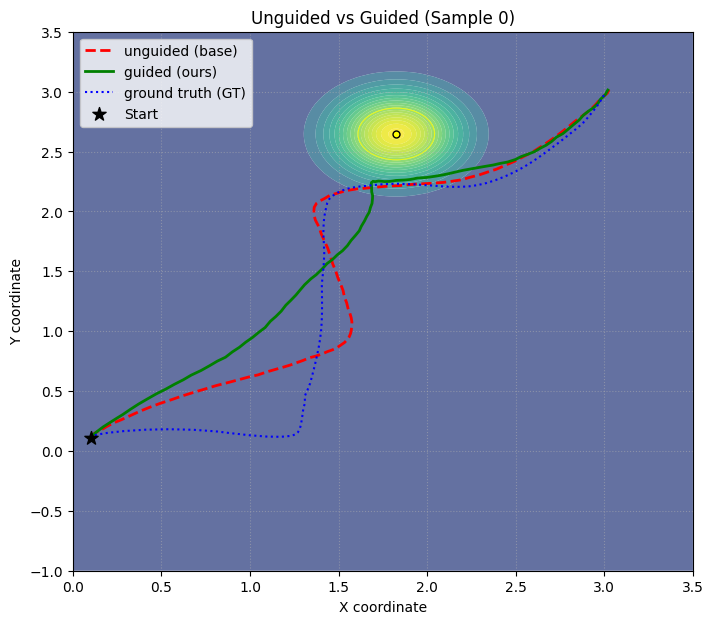

In [49]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

# --- 1. 检查依赖 ---
print("正在验证...")
required_vars = ['traj_base', 'traj_guided', 'metric', 'dist_coeffs_for_eval', 
                 'mask_for_eval', 'gt_batch', 'distribution', 'gp_batch']
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"缺少来自 Cell C 的变量: {v}。请先运行 Cell C。")

# --- 2. 计算指标 ---
with torch.no_grad():
    # 2.1 遍历性度量 (E)
    E_base = metric.energy(traj_base, dist_coeffs_for_eval, mask_for_eval).mean().item()
    E_guid = metric.energy(traj_guided, dist_coeffs_for_eval, mask_for_eval).mean().item()
    
    # --- 关键新增：计算 GT 的 E 值 ---
    E_gt = metric.energy(gt_batch, dist_coeffs_for_eval, mask_for_eval).mean().item()
    # --- 结束新增 ---
    
    # 2.2 均方误差 (MSE)
    mask_expanded = mask_for_eval.unsqueeze(-1).to(gt_batch.dtype)
    mse_base_total = (((traj_base - gt_batch)**2) * mask_expanded).sum()
    mse_guid_total = (((traj_guided - gt_batch)**2) * mask_expanded).sum()
    total_valid_steps = mask_expanded.sum()
    
    mse_base = (mse_base_total / total_valid_steps).item()
    mse_guid = (mse_guid_total / total_valid_steps).item()
    
    # 2.3 引导偏移量
    diff_norm = torch.norm((traj_guided - traj_base).view(B, -1), dim=1).mean().item()

# --- 3. 打印报告 (更新版) ---
print('---- xt-corrector (v5) Metrics ----')
print(f"度量衡:        {metric.__class__.__name__}")

# --- 更新：显示所有三个 E 值 ---
print(f"Energy (E) GT:   {E_gt:.6f} (理论最优基准)")
print(f"Energy (E) base: {E_base:.6f} (无引导)")
print(f"Energy (E) guid: {E_guid:.6f} (有引导)")

# --- 更新：计算详细的 Delta ---
delta_base_to_gt = E_base - E_gt
delta_guid_to_gt = E_guid - E_gt
delta_base_to_guid = E_base - E_guid

print(f"  > 改进空间 (Base -> GT):   {(delta_base_to_gt):.6f} (Base与最优的差距)")
print(f"  > 引导效果 (Base -> Guid): {(delta_base_to_guid):.6f} (正值表示引导有效)")
print(f"  > 最终差距 (Guid -> GT):   {(delta_guid_to_gt):.6f} (Guid与最优的差距)")
print("")
print(f"MSE (vs GT):     base={mse_base:.6f}, guided={mse_guid:.6f}")
print(f"  > 轨迹保真度 (Δ):  {(mse_base - mse_guid):.6f} (正值表示引导更接近 GT)")
print(f"‖guided - base‖: {diff_norm:.4f} (引导施加的修正强度)")


# --- 4. 可视化对比 (使用 GMM 组件渲染逻辑) ---
# (此部分保持不变)
print("正在绘制对比图 (使用 GMM 组件背景)...")

# Cell EnergyD: 修正 draw_gaussian_components_summed 函数 (v7: 使用 Zip 迭代器)

def draw_gaussian_components_summed(ax, params, x0, x1, y0, y1, pnorm):
    GRID_RES = 150 
    LEVELS = 20    
    
    n = int(params["n"])
    
    # 1. 准备原始数据并强制重塑为 [N, D] 结构，防止索引错误
    C_raw = np.asarray(params["centers"])
    V_raw = np.asarray(params["covs"])
    W_raw = np.asarray(params["weights"])

    # C, V, W 必须确保维度是 [N, D] 或 [N]
    # 我们信任 n 的值是正确的
    C = C_raw.reshape(-1, 2)[:n] 
    V = V_raw.reshape(-1, 4)[:n]
    W = np.atleast_1d(W_raw)[:n] # 保持 [N] 形状
    
    # --------------------------------------------------------

    xs = np.linspace(x0, x1, GRID_RES)
    ys = np.linspace(y0, y1, GRID_RES)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")

    Z_total = np.zeros_like(Xg)
    
    # --- CRITICAL FIX: 使用 zip 迭代器，消除索引冲突 ---
    
    # Loop 1: 计算 Z_total
    # zip 会安全地迭代 n 次，自动处理 C[i] 的解包
    for center, cov, weight in zip(C, V, W):
        # Line 97 修正：直接解包 center (形状 [2])
        cx, cy = center 
        
        # 提取标量精度 c_xx (cov 是 [4] 数组)
        c = float(cov[0]) 
        w = float(weight) 
        
        if c <= 0 or w <= 0:
            continue
        
        Z_total += w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
    
    if Z_total.max() > 1e-6:
         ax.contourf(Xg, Yg, Z_total, levels=LEVELS, cmap="viridis", norm=pnorm, alpha=0.8, antialiased=True)

    # Loop 2: 绘制标记
    for center, cov, weight in zip(C, V, W):
        cx, cy = center
        c = float(cov[0])
        
        r = float(np.sqrt(max(1e-8, 0.5 / c))) 
        
        ax.scatter([cx],[cy], c="yellow", edgecolors="k", s=25, zorder=3)
        circ = Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.8)
        ax.add_patch(circ)

i = np.random.randint(0, B)

# --- 关键修正：处理 B=1 塌陷 ---
n_gauss_tensor = gp_batch['n_gaussians']

# 如果 tensor 是 0 维，直接取值 (.item())；否则按批次索引 [i]
if n_gauss_tensor.ndim == 0:
    n_gauss_val = n_gauss_tensor.item() 
else:
    n_gauss_val = n_gauss_tensor[i].item() 
# ----------------------------

gp_i = {
    "n": n_gauss_val,
    "centers": gp_batch['centers'][i].cpu().numpy(),
    "covs":    gp_batch['covs'][i].cpu().numpy(),
    "weights": gp_batch['weights'][i].cpu().numpy(),
}

xmin, xmax = metric.xmin, metric.xmax
ymin, ymax = metric.ymin, metric.ymax
pnorm = PowerNorm(gamma=0.4)

plt.figure(figsize=(8, 7))
plt.title(f'Unguided vs Guided (Sample {i})')
ax = plt.gca()

draw_gaussian_components_summed(ax, gp_i, xmin, xmax, ymin, ymax, pnorm)

valid_len_for_plot = int(mask_for_eval[i].sum().item())

plt.plot(traj_base[i, :valid_len_for_plot, 0].detach().cpu(), 
         traj_base[i, :valid_len_for_plot, 1].detach().cpu(), 
         'r--', lw=2, label='unguided (base)')
plt.plot(traj_guided[i, :valid_len_for_plot, 0].detach().cpu(), 
         traj_guided[i, :valid_len_for_plot, 1].detach().cpu(), 
         'g-', lw=2, label='guided (ours)')
plt.plot(gt_batch[i, :valid_len_for_plot, 0].detach().cpu(), 
         gt_batch[i, :valid_len_for_plot, 1].detach().cpu(), 
         'b:', lw=1.5, label='ground truth (GT)')

plt.scatter(traj_guided[i, 0, 0].detach().cpu(), 
            traj_guided[i, 0, 1].detach().cpu(), 
            c='black', s=100, zorder=10, marker='*', label='Start')

plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

## Cell Energy Test1-验证基础模型的有效性

In [ ]:
import torch
import copy
from types import SimpleNamespace as NS
from models.diffusion_utils.sampling import dpm_sampler

# --- 1. 检查依赖 ---
if 'model' not in globals():
    raise RuntimeError('请先运行 Cell 10 加载模型。')
# ... (其他检查) ...

# --- 2. 准备特定样本 (Sample 0) ---
TARGET_IDX = 0  # <--- 我们锁定 "坏样本"
N_SAMPLES = 100 # <-- 我们要采样的次数

print(f"正在加载特定样本: idx={TARGET_IDX}...")
try:
    s = val_loader.dataset[TARGET_IDX]
except Exception as e:
    print(f"警告：无法通过索引 {TARGET_IDX} 加载。回退到使用 val_loader.dataset[0]。")
    print(f"(错误: {e})")
    TARGET_IDX = 0
    s = val_loader.dataset[TARGET_IDX]

# 2.2. 手动构建批次 (B=1)
rsn = model.config.normalizer.robot_state
mean_cpu = torch.as_tensor(rsn.mean, device='cpu')
std_cpu = torch.as_tensor(rsn.std, device='cpu')

distribution = s["distribution"].unsqueeze(0).to(device)
gt_batch = s["trajectories"].unsqueeze(0).to(device)

rs_phys = s["robot_state"].view(1, -1).to('cpu')
robot_state_norm = (rs_phys - mean_cpu) / std_cpu # [1, 4]
robot_state_norm = robot_state_norm.to(device)

gp = s["gaussian_params"]
gp_batch = {
    "n_gaussians": torch.tensor([gp["n_gaussians"]], device=device, dtype=torch.long),
    "centers": torch.as_tensor(gp["centers"], device=device, dtype=torch.float32).unsqueeze(0),
    "covs":    torch.as_tensor(gp["covs"], device=device, dtype=torch.float32).unsqueeze(0),
    "weights": torch.as_tensor(gp["weights"], device=device, dtype=torch.float32).unsqueeze(0),
}

T = model.config.data.trajectory_len
D = model.config.robot_state_dim
steps = 80 

print(f"样本 {TARGET_IDX} 加载完毕。B=1。")

# --- 3. 运行 N 次基线 (无引导) 采样 ---
print(f"正在对 Sample {TARGET_IDX} 运行 {N_SAMPLES} 次无引导采样...")
all_traj_base = []

with torch.no_grad():
    
    # --- 关键修正：构造 Encoder 期望的完整输入字典 ---
    encoder_inputs = {
        'distribution': distribution, 
        'robot_state': robot_state_norm,
        'gaussian_packed': gmm_packed,
        'gaussian_padding_mask': gmm_mask
    }
    # ----------------------------------------------
    
    enc = model.encoder(encoder_inputs) # <--- 修正点：使用完整的输入字典
    context = enc['encoding']
    rs_denorm = denorm_robot_state(robot_state_norm, mean, std) # 使用本地 mean/std
    other_params = {'context': context, 'conditions': {0: rs_denorm}}
    
    for i in range(N_SAMPLES):
        # 每次都用新的随机种子
        x_T_base = torch.randn(1, T * D, device=device) # B=1
        
        traj_base_i = dpm_sampler(model=model.decoder.dit, x_T=x_T_base,
                                other_model_params=other_params, 
                                diffusion_steps=steps).view(1, T, D) # B=1
        traj_base_i[:, 0, :] = rs_denorm
        all_traj_base.append(traj_base_i)

# --- 4. 准备用于验证的大批次 (B=N_SAMPLES) ---
traj_base_batch = torch.cat(all_traj_base, dim=0) # [N_SAMPLES, T, D]

# (实例化度量，为 D 做准备)
METRIC_BOUNDS = ((0.0, 3.5), (-1.0, 3.5)) 
metric = FourierErgodic(bounds=METRIC_BOUNDS, max_mode=6, lambda_power=1.25)

# (为 D 准备重复的 GT 和系数)
print("正在为验证准备批处理数据...")
gt_batch_repeated = gt_batch.repeat(N_SAMPLES, 1, 1) # [N_SAMPLES, T, D]

# (为 D 准备重复的掩码)
with torch.no_grad():
    # 我们只用 GT[0] 来创建掩码
    padding_eps = 1e-8
    valid_mask_single = (gt_batch[0].abs().sum(dim=-1) > padding_eps) # [T]
    valid_mask_single[0] = True
    mask_for_eval = valid_mask_single.unsqueeze(0).repeat(N_SAMPLES, 1) # [N_SAMPLES, T]

# (为 D 准备重复的分布系数)
dist_coeffs_single = metric.compute_coefficients(distribution[0, 0]) # [K+1, K+1]
dist_coeffs_for_eval = dist_coeffs_single.unsqueeze(0).repeat(N_SAMPLES, 1, 1) # [N_SAMPLES, K+1, K+1]

print("多样本采样完成。")
print(f"全局变量已准备就绪: 'traj_base_batch' (B={N_SAMPLES}), 'gt_batch' (B=1), ...")

import matplotlib.pyplot as plt
import torch
import numpy as np
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

# --- 1. 检查依赖 ---
print("正在验证分布...")
required_vars = ['traj_base_batch', 'metric', 'dist_coeffs_for_eval', 
                 'mask_for_eval', 'gt_batch'] # (gt_batch 保持 B=1)
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"缺少来自 Cell C 的变量: {v}。请先运行 Cell C。")

N_SAMPLES = traj_base_batch.shape[0]
gt_batch_single = gt_batch[0] # [T, D]
mask_single = mask_for_eval[0] # [T]
dist_coeffs_single = dist_coeffs_for_eval[0] # [K+1, K+1]

# --- 2. 计算指标统计 ---
with torch.no_grad():
    # 2.1 E_gt (理论基准)
    # (我们只计算一次 GT 的)
    E_gt_val = metric.energy(gt_batch_single.unsqueeze(0), 
                             dist_coeffs_single.unsqueeze(0), 
                             mask_single.unsqueeze(0)).mean().item()

    # 2.2 E_base (100个样本的向量)
    print(f"正在计算 {N_SAMPLES} 条轨迹的 E 值...")
    E_base_vec = metric.energy(traj_base_batch, 
                               dist_coeffs_for_eval, 
                               mask_for_eval).detach().cpu().numpy()

    # 2.3 MSE_base (100个样本的向量)
    print(f"正在计算 {N_SAMPLES} 条轨迹的 MSE 值...")
    mask_expanded_single = mask_single.unsqueeze(-1).to(gt_batch.dtype) # [T, 1]
    total_valid_steps = mask_expanded_single.sum()
    
    mse_vec = []
    for i in range(N_SAMPLES):
        traj_i = traj_base_batch[i] # [T, D]
        mse = (((traj_i - gt_batch_single)**2) * mask_expanded_single).sum() / total_valid_steps
        mse_vec.append(mse.item())
    mse_vec = np.array(mse_vec)

# --- 3. 打印统计报告 ---
print('---- Unguided Distribution Metrics (N_SAMPLES={}) ----'.format(N_SAMPLES))
print(f"度量衡:        {metric.__class__.__name__}")
print(f"Energy (E) GT:   {E_gt_val:.6f} (理论最优基准)")
print("")
print("--- 遍历能量 (E) 统计 ---")
print(f"  E_base (Mean): {E_base_vec.mean():.6f}")
print(f"  E_base (Std):  {E_base_vec.std():.6f}  <--- (看这个值，如果很小，猜想成立)")
print(f"  E_base (Min):  {E_base_vec.min():.6f}")
print(f"  E_base (Max):  {E_base_vec.max():.6f}")
print("")
print("--- 几何误差 (MSE) 统计 ---")
print(f"  MSE (Mean): {mse_vec.mean():.6f}")
print(f"  MSE (Std):  {mse_vec.std():.6f}  <--- (看这个值，如果很大，猜想成立)")
print(f"  MSE (Min):  {mse_vec.min():.6f}")
print(f"  MSE (Max):  {mse_vec.max():.6f}")

# --- 4. 可视化分布 (直方图) ---
print("正在绘制统计分布图...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图 1: E 值的直方图
axes[0].set_title("E (遍历能量) 分布 (N=100)")
axes[0].hist(E_base_vec, bins=20, alpha=0.7, label="Base (unguided) Samples")
axes[0].axvline(E_gt_val, color='b', linestyle='--', lw=2, label=f"E_gt = {E_gt_val:.4f}")
axes[0].set_xlabel("Energy (E)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 图 2: MSE 值的直方图
axes[1].set_title("MSE (几何误差) 分布 (N=100)")
axes[1].hist(mse_vec, bins=20, alpha=0.7, color='r', label="Base (unguided) Samples")
axes[1].set_xlabel("MSE (vs GT)")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 图 3: 能量 vs 误差 散点图
axes[2].set_title("MSE vs Energy")
axes[2].scatter(mse_vec, E_base_vec, alpha=0.5)
axes[2].set_xlabel("MSE (几何误差)")
axes[2].set_ylabel("Energy (E)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cell Energy Test2-纯能量优化测试

In [ ]:
# 验证实验 1: 纯能量梯度下降 (不使用 Diffusion)
# 目的: 测试傅里叶度量的梯度场是否能引导直线变弯

import torch
import matplotlib.pyplot as plt

# 1. 准备数据 (Sample 0)
s = val_loader.dataset[0]
gt = s["trajectories"].to(device) # [T, 4]
rs = s["robot_state"].to(device)
dist = s["distribution"].unsqueeze(0).to(device) # [1, 1, H, W]

# 2. 创建一条从起点到终点的"直线"作为初始猜测
T, D = gt.shape
start_pos = gt[0, :2]
end_pos = gt[-1, :2]
# 线性插值生成直线
init_traj = torch.zeros(T, 2, device=device)
for t in range(T):
    alpha = t / (T - 1)
    init_traj[t] = (1 - alpha) * start_pos + alpha * end_pos

# 3. 定义优化变量
# 我们只优化中间的点，固定起点
opt_traj = init_traj.clone().detach().requires_grad_(True)
optimizer = torch.optim.Adam([opt_traj], lr=0.05)

# 4. 准备度量
metric = FourierErgodic(bounds=((0.0, 3.5), (-1.0, 3.5)), max_mode=6)
# 计算目标系数
rho = dist[0, 0]
coeffs = metric.compute_coefficients(rho).unsqueeze(0) # [1, K+1, K+1]

# 5. 开始纯梯度下降
print("开始纯能量优化...")
losses = []
for i in range(200):
    optimizer.zero_grad()
    
    # 增加 Batch 维度 [1, T, 2]
    traj_in = opt_traj.unsqueeze(0)
    
    # 计算 E
    # 注意: 这里我们没有 mask，假设全是有效的
    loss = metric.energy(traj_in, coeffs).sum()
    
    loss.backward()
    
    # 固定起点 (简单的 Projected Gradient)
    with torch.no_grad():
        opt_traj.grad[0, :] = 0 
        
    optimizer.step()
    losses.append(loss.item())
    
    if i % 50 == 0:
        print(f"Iter {i}, E = {loss.item():.6f}")

# 6. 可视化
print(f"Final E: {losses[-1]:.6f} (GT E: {0.094:.6f})")
plt.figure(figsize=(6, 6))
# 画背景
plt.imshow(rho.cpu().numpy(), origin='lower', extent=(0, 3.5, -1, 3.5), alpha=0.6)
# 画轨迹
plt.plot(gt[:, 0].cpu().numpy(), gt[:, 1].cpu().numpy(), 'b:', label='GT')
plt.plot(init_traj[:, 0].cpu().numpy(), init_traj[:, 1].cpu().numpy(), 'r--', label='Initial (Line)')
plt.plot(opt_traj.detach().cpu().numpy()[:, 0], opt_traj.detach().cpu().numpy()[:, 1], 'g-', lw=3, label='Optimized')
plt.legend()
plt.title("Pure Optimization Test")
plt.show()

## Cell 12 — 可视化 Pred vs GT（随机 12 条 + heatmap 背景）
- 从验证子集随机采样 12 条（seed=123），在分布热力图背景上绘制 Pred/GT，对齐“最后有效步”，保存单图与 3×4 网格图

In [ ]:
# 12 Qualitative visualization: Pred vs GT with per-Gaussian components (random 12, seed=123)

import os, torch, numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

# 工作空间基准（用于默认尺度）；实际仍用“动态范围”
WORKSPACE_BOUNDS = ((0.0, 3.0), (0.0, 3.0))
X0, X1 = WORKSPACE_BOUNDS[0]
Y0, Y1 = WORKSPACE_BOUNDS[1]

def last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

# 从验证集随机抽样 12 条
try:
    val_indices = list(val_loader.sampler.indices)
except Exception:
    val_indices = list(range(len(val_loader.dataset)))
rng = np.random.RandomState(123)
pick = rng.choice(val_indices, size=12, replace=False).tolist()

# 收集样本
dists, rs_std, gts, comp_params = [], [], [], []  # 不再使用合成网格
rsn = model.config.normalizer.robot_state
mean = rsn.mean; std = rsn.std

for idx in pick:
    s = val_loader.dataset[idx]
    dists.append(s["distribution"].unsqueeze(0))       # 仍收集，备用（本格不用）
    gts.append(s["trajectories"].unsqueeze(0))         # [1,T,4]
    rs_phys = s["robot_state"].view(1, -1).to(device=torch.device("cpu"), dtype=torch.float32)
    rs_std.append(((rs_phys - mean.cpu().view(1,-1)) / (std.cpu().view(1,-1))).unsqueeze(0))  # [1,1,4]
    gp = s["gaussian_params"]
    comp_params.append({
        "n": int(gp["n_gaussians"]),
        "centers": gp["centers"].cpu().numpy() if isinstance(gp["centers"], torch.Tensor) else gp["centers"],
        "covs":    gp["covs"].cpu().numpy()    if isinstance(gp["covs"], torch.Tensor)    else gp["covs"],
        "weights": gp["weights"].cpu().numpy() if isinstance(gp["weights"], torch.Tensor) else gp["weights"],
    })

dist_batch   = torch.cat(dists, dim=0).to(device)            # [N,1,H,W] 仅为保持接口一致（此处不使用）
rs_std_batch = torch.cat(rs_std, dim=0).squeeze(1).to(device)  # [N,4]
gt_batch     = torch.cat(gts, dim=0)                        # [N,T,4]
N = gt_batch.shape[0]

# 推理
model.eval()
with torch.no_grad():
    out = model.inference({"distribution": dist_batch, "robot_state": rs_std_batch})
pred_batch = out["prediction"].detach().cpu().numpy()
gt_batch_np = gt_batch.numpy()

# 绘图参数
pnorm = PowerNorm(gamma=0.7)  # 0.4~0.8 更突出峰值
LEVELS = 20                   # 等高线层数
GRID_RES = 150                # 分量背景网格分辨率（越大越细致）

# 输出目录
vis_dir = "trained/vis"
os.makedirs(vis_dir, exist_ok=True)

def draw_gaussian_components(ax, params, x0, x1, y0, y1):
    """
    params: dict {n, centers(10,2), covs(10), weights(10)}
    使用 z_i = w_i * exp(-c_i*((x-cx)^2+(y-cy)^2)) 绘制每个分量，不叠加
    """
    n = int(params["n"])
    C = np.asarray(params["centers"])[:n]
    V = np.asarray(params["covs"])[:n]
    W = np.asarray(params["weights"])[:n]
    # 构造物理坐标网格
    xs = np.linspace(x0, x1, GRID_RES)
    ys = np.linspace(y0, y1, GRID_RES)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")

    for i in range(n):
        cx, cy = C[i]
        c = float(V[i])
        w = float(W[i])
        if c <= 0 or w <= 0:
            continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        # 用 contourf + contour 叠加此分量（不累加），alpha 小一些
        ax.contourf(Xg, Yg, Z, levels=LEVELS, cmap="viridis", norm=pnorm, alpha=0.6, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=LEVELS//4, colors="k", linewidths=0.3, alpha=0.25)
        # 画中心与 1σ 近似圈（r = sqrt(0.5/c)）
        r = float(np.sqrt(max(1e-8, 0.5 / c)))
        ax.scatter([cx],[cy], c="yellow", edgecolors="k", s=25, zorder=3)
        circ = Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.8)
        ax.add_patch(circ)

# 单图（每个样本单独 png）
for i in range(N):
    xy_gt = gt_batch_np[i, :, :2]
    xy_pr = pred_batch[i, :, :2]
    k = last_valid_idx_xy_np(xy_gt)

    # 动态范围 + 3% padding
    x_min = min(X0, xy_gt[:k+1,0].min(), xy_pr[:k+1,0].min())
    x_max = max(X1, xy_gt[:k+1,0].max(), xy_pr[:k+1,0].max())
    y_min = min(Y0, xy_gt[:k+1,1].min(), xy_pr[:k+1,1].min())
    y_max = max(Y1, xy_gt[:k+1,1].max(), xy_pr[:k+1,1].max())
    pad = 0.03 * max(X1 - X0, Y1 - Y0)
    x0, x1 = x_min - pad, x_max + pad
    y0, y1 = y_min - pad, y_max + pad

    fig, ax = plt.subplots(figsize=(4,4))
    # 绘制“每个高斯分量”的等高填色与等高线
    draw_gaussian_components(ax, comp_params[i], x0, x1, y0, y1)

    # 叠加轨迹（只到最后有效步）
    ax.plot(xy_gt[:k+1,0], xy_gt[:k+1,1], 'g-', lw=2, label="GT")
    ax.plot(xy_pr[:k+1,0], xy_pr[:k+1,1], 'r--', lw=2, label="Pred")
    ax.scatter(xy_gt[0,0], xy_gt[0,1], c='k', s=20)

    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)
    ax.set_title(f"sample idx={pick[i]}")
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(vis_dir, f"trajectory_{pick[i]}_components.png"), dpi=170)
    plt.close(fig)

print(f"Saved individual per-component figures -> {vis_dir}")

# 3×4 网格
fig = plt.figure(figsize=(12,9))
gs = GridSpec(3, 4, figure=fig, wspace=0.25, hspace=0.25)
for i in range(N):
    ax = fig.add_subplot(gs[i//4, i%4])
    xy_gt = gt_batch_np[i, :, :2]
    xy_pr = pred_batch[i, :, :2]
    k = last_valid_idx_xy_np(xy_gt)

    x_min = min(X0, xy_gt[:k+1,0].min(), xy_pr[:k+1,0].min())
    x_max = max(X1, xy_gt[:k+1,0].max(), xy_pr[:k+1,0].max())
    y_min = min(Y0, xy_gt[:k+1,1].min(), xy_pr[:k+1,1].min())
    y_max = max(Y1, xy_gt[:k+1,1].max(), xy_pr[:k+1,1].max())
    pad = 0.03 * max(X1 - X0, Y1 - Y0)
    x0, x1 = x_min - pad, x_max + pad
    y0, y1 = y_min - pad, y_max + pad

    draw_gaussian_components(ax, comp_params[i], x0, x1, y0, y1)
    ax.plot(xy_gt[:k+1,0], xy_gt[:k+1,1], 'g-', lw=1.5)
    ax.plot(xy_pr[:k+1,0], xy_pr[:k+1,1], 'r--', lw=1.5)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)
    ax.set_title(str(pick[i]), fontsize=9)

plt.suptitle("Pred vs GT (random 12, seed=123) with per-Gaussian components", fontsize=12)
plt.savefig(os.path.join(vis_dir, "grid_12_components.png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved grid -> {os.path.join(vis_dir, 'grid_12_components.png')}")


## Cell 13 - 轨迹 GIF(单样本逐步动画)
若想指定样本，修改 SAMPLE_IDX = <val_index>；否则保持 None 会随机抽取。
若动画太慢，可将 STRIDE 提大（如 2 或 3）跳帧播放；或降低 GRID_RES/LEVELS。
若希望 GIF 更清晰，可把 figsize 或 dpi（在 PillowWriter 不便设置时，用 imageio 分支拼帧前 fig2.set_dpi(120)）调高。

In [ ]:
# 13 Trajectory GIF (single sample, step-by-step animation with per-Gaussian background)

import os, math, numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# ------------ 配置 ------------
SAMPLE_IDX = None      # 指定验证集中某条样本索引；None 表示随机抽取一条
SEED = 123             # 随机抽样种子
STEPS = int(getattr(getattr(model.config, "diffusion", object()), "steps", 100))  # 采样步数
FPS = 15               # GIF 帧率
STRIDE = 1             # 帧间步长（>1 可加快动画）
GRID_RES = 160         # 背景网格分辨率（越大越细）
LEVELS = 22            # 等高线层数
GAMMA = 0.7            # PowerNorm gamma（<1 增强峰值对比）

# ------------ 工具函数 ------------
def last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

def draw_gaussian_components(ax, params, x0, x1, y0, y1, grid_res=GRID_RES, levels=LEVELS, gamma=GAMMA):
    """逐分量绘制等高填色与等高线，并标注中心与 1σ 近似圈。"""
    pnorm = PowerNorm(gamma=gamma)
    n = int(params["n"])
    C = np.asarray(params["centers"])[:n]
    V = np.asarray(params["covs"])[:n]
    W = np.asarray(params["weights"])[:n]
    xs = np.linspace(x0, x1, grid_res)
    ys = np.linspace(y0, y1, grid_res)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    for i in range(n):
        cx, cy = C[i]; c = float(V[i]); w = float(W[i])
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=levels, cmap="viridis", norm=pnorm, alpha=0.7, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=max(3, levels//4), colors="k", linewidths=0.3, alpha=0.25)
        r = float(np.sqrt(max(1e-8, 0.5 / c)))  # 近似 1σ
        ax.scatter([cx], [cy], c="yellow", edgecolors="k", s=25, zorder=3)
        ax.add_patch(Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.9))

# ------------ 选样本 ------------
try:
    val_indices = list(val_loader.sampler.indices)
except Exception:
    val_indices = list(range(len(val_loader.dataset)))

if SAMPLE_IDX is None:
    rng = np.random.RandomState(SEED)
    SAMPLE_IDX = int(rng.choice(val_indices, size=1)[0])

s = val_loader.dataset[SAMPLE_IDX]
print("Making GIF for sample idx:", SAMPLE_IDX)

# 取输入
dist = s["distribution"].unsqueeze(0).to(device)   # [1,1,H,W]
gt   = s["trajectories"].unsqueeze(0)              # [1,T,4] (CPU)
rsn = model.config.normalizer.robot_state
rs_phys = s["robot_state"].view(1, -1).to(dtype=torch.float32, device=torch.device("cpu"))
rs_std  = ((rs_phys - rsn.mean.cpu().view(1,-1)) / (rsn.std.cpu().view(1,-1))).to(device)  # [1,4]

# 推理
with torch.no_grad():
    out = model.inference({"distribution": dist, "robot_state": rs_std})
pred = out["prediction"].detach().cpu().numpy()[0]     # [T,4]
gt_np= gt.numpy()[0]                                   # [T,4]
k = last_valid_idx_xy_np(gt_np[:, :2])

# 高斯参数
gp = s["gaussian_params"]
params = {
    "n": int(gp["n_gaussians"]),
    "centers": gp["centers"].cpu().numpy() if isinstance(gp["centers"], torch.Tensor) else gp["centers"],
    "covs":    gp["covs"].cpu().numpy()    if isinstance(gp["covs"], torch.Tensor)    else gp["covs"],
    "weights": gp["weights"].cpu().numpy() if isinstance(gp["weights"], torch.Tensor) else gp["weights"],
}

# 动态范围（含 3% 边距）
X0_def, X1_def = 0.0, 3.0
Y0_def, Y1_def = 0.0, 3.0
x_min = min(X0_def, gt_np[:k+1,0].min(), pred[:k+1,0].min())
x_max = max(X1_def, gt_np[:k+1,0].max(), pred[:k+1,0].max())
y_min = min(Y0_def, gt_np[:k+1,1].min(), pred[:k+1,1].min())
y_max = max(Y1_def, gt_np[:k+1,1].max(), pred[:k+1,1].max())
pad = 0.03 * max(X1_def - X0_def, Y1_def - Y0_def)
x0, x1 = x_min - pad, x_max + pad
y0, y1 = y_min - pad, y_max + pad

# ------------ 准备动画 ------------
fig, ax = plt.subplots(figsize=(5,5))
# 背景一次性绘制
draw_gaussian_components(ax, params, x0, x1, y0, y1)

# 轨迹对象
(gt_line,)   = ax.plot([], [], 'g-', lw=2, label="GT")
(pred_line,) = ax.plot([], [], 'r--', lw=2, label="Pred")
pred_tip = ax.scatter([], [], c='red', s=22, zorder=4)
ax.scatter([gt_np[0,0]], [gt_np[0,1]], c='k', s=20)   # 起点
ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
ax.set_aspect('equal'); ax.grid(alpha=0.25)
ax.set_title(f"sample idx={SAMPLE_IDX}")
ax.legend(loc="best", fontsize=9)

# 帧更新
T_frames = (k + 1 + STRIDE - 1) // STRIDE  # ceil((k+1)/stride)
def update(frame_idx):
    t = min(k, frame_idx * STRIDE)
    gt_line.set_data(gt_np[:t+1,0],   gt_np[:t+1,1])
    pred_line.set_data(pred[:t+1,0],  pred[:t+1,1])
    pred_tip.set_offsets([[pred[t,0], pred[t,1]]])
    return gt_line, pred_line, pred_tip

ani = FuncAnimation(fig, update, frames=T_frames, interval=1000/FPS, blit=False)
plt.close(fig)

# ------------ 保存 GIF ------------
gif_dir = os.path.join("trained", "vis", "gifs")
os.makedirs(gif_dir, exist_ok=True)
gif_path = os.path.join(gif_dir, f"trajectory_{SAMPLE_IDX}.gif")
try:
    ani.save(gif_path, writer=PillowWriter(fps=FPS))
except Exception as e:
    # 退化方案：用 imageio 手动拼帧
    import imageio.v2 as imageio
    frames = []
    fig2, ax2 = plt.subplots(figsize=(5,5))
    draw_gaussian_components(ax2, params, x0, x1, y0, y1)
    (gt_line2,)   = ax2.plot([], [], 'g-', lw=2)
    (pred_line2,) = ax2.plot([], [], 'r--', lw=2)
    pred_tip2 = ax2.scatter([], [], c='red', s=22)
    ax2.scatter([gt_np[0,0]], [gt_np[0,1]], c='k', s=20)
    ax2.set_xlim(x0, x1); ax2.set_ylim(y0, y1); ax2.set_aspect('equal'); ax2.grid(alpha=0.25)
    ax2.set_title(f"sample idx={SAMPLE_IDX}")
    for fi in range(T_frames):
        t = min(k, fi * STRIDE)
        gt_line2.set_data(gt_np[:t+1,0],   gt_np[:t+1,1])
        pred_line2.set_data(pred[:t+1,0],  pred[:t+1,1])
        pred_tip2.set_offsets([[pred[t,0], pred[t,1]]])
        fig2.canvas.draw()
        frame = np.frombuffer(fig2.canvas.tostring_rgb(), dtype=np.uint8)
        frame = frame.reshape(fig2.canvas.get_width_height()[::-1] + (3,))
        frames.append(frame)
    plt.close(fig2)
    imageio.mimsave(gif_path, frames, fps=FPS)

print("Saved GIF ->", gif_path)


## Cell 14 - 扩散过程 GIF (从噪声收敛到轨迹)

In [ ]:
# 14 Diffusion path GIF (analytic) — lock start, skip-first, ease-out, hold-final, non-loop

import os, numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import PowerNorm
from matplotlib.patches import Circle
from models.diffusion_utils.sampling import dpm_sampler  # 允许

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# ---------- 控制量 ----------
SAMPLE_IDX     = None   # None=随机选一条验证样本
SEED           = 123
STEPS_SOLVER   = int(getattr(getattr(model.config, "diffusion", object()), "steps", 100))
N_FRAMES       = 24
FPS            = 6
HOLD_FINAL_SEC = 2.0
EASE           = "ease_out"  # 或 "none"
EASE_POWER     = 0.6         # 0.4~0.7，越小末端越密集
SKIP_FIRST_NOISY_FRAMES = 2  # 跳过最前噪声帧（0=不跳）
LOCK_START     = True        # 每帧第0时刻锁定到物理起点

GRID_RES = 160
LEVELS   = 20
GAMMA    = 0.7

def last_valid_idx_xy_np(xy, eps=1e-12):
    valid = ~(np.all(np.abs(xy) <= eps, axis=1))
    return np.nonzero(valid)[0][-1] if valid.any() else (xy.shape[0]-1)

def draw_gaussian_components(ax, params, x0, x1, y0, y1, grid_res=GRID_RES, levels=LEVELS, gamma=GAMMA):
    pnorm = PowerNorm(gamma=gamma)
    n = int(params["n"])
    C = np.asarray(params["centers"])[:n]
    V = np.asarray(params["covs"])[:n]
    W = np.asarray(params["weights"])[:n]
    xs = np.linspace(x0, x1, grid_res)
    ys = np.linspace(y0, y1, grid_res)
    Xg, Yg = np.meshgrid(xs, ys, indexing="xy")
    for i in range(n):
        cx, cy = C[i]; c = float(V[i]); w = float(W[i])
        if c <= 0 or w <= 0: continue
        Z = w * np.exp(-c * ((Xg - cx)**2 + (Yg - cy)**2))
        ax.contourf(Xg, Yg, Z, levels=levels, cmap="viridis", norm=pnorm, alpha=0.7, antialiased=True)
        ax.contour( Xg, Yg, Z, levels=max(3, levels//4), colors="k", linewidths=0.3, alpha=0.25)
        r = float(np.sqrt(max(1e-8, 0.5 / c)))
        ax.scatter([cx], [cy], c="yellow", edgecolors="k", s=25, zorder=3)
        ax.add_patch(Circle((cx, cy), r, edgecolor="yellow", facecolor="none", lw=0.7, alpha=0.9))

# 选样本
try:
    val_indices = list(val_loader.sampler.indices)
except Exception:
    val_indices = list(range(len(val_loader.dataset)))
if SAMPLE_IDX is None:
    rng = np.random.RandomState(SEED)
    SAMPLE_IDX = int(rng.choice(val_indices, size=1)[0])
s = val_loader.dataset[SAMPLE_IDX]
print("Analytic diffusion GIF for sample idx:", SAMPLE_IDX)

# 输入
dist = s["distribution"].unsqueeze(0).to(device)
gt   = s["trajectories"].unsqueeze(0)              # CPU
rsn  = model.config.normalizer.robot_state
rs_phys = s["robot_state"].view(1, -1).to(dtype=torch.float32, device=torch.device("cpu"))
rs_std  = ((rs_phys - rsn.mean.cpu().view(1,-1)) / (rsn.std.cpu().view(1,-1))).to(device)

# 高斯参数
gp = s["gaussian_params"]
params = {
    "n": int(gp["n_gaussians"]),
    "centers": gp["centers"].cpu().numpy() if isinstance(gp["centers"], torch.Tensor) else gp["centers"],
    "covs":    gp["covs"].cpu().numpy()    if isinstance(gp["covs"], torch.Tensor)    else gp["covs"],
    "weights": gp["weights"].cpu().numpy() if isinstance(gp["weights"], torch.Tensor) else gp["weights"],
}

# 编码 & 固定 x_T
with torch.no_grad():
    enc_out = model.encoder({"distribution": dist, "robot_state": rs_std})
context = enc_out["encoding"]
other   = {"context": context, "conditions": {0: rs_phys.to(device)}}
gen = torch.Generator(device=device).manual_seed(SEED)
x_T = torch.randn(1, model.decoder.output_dim, device=device, generator=gen)

# 先求 x0
with torch.no_grad():
    # 构造 x0 修正器（A2 里定义的函数）
    # 注意：gp 与 dist 需要带 batch 维 [1,...]
    gp_b = {
        "centers":  gp["centers"].unsqueeze(0) if isinstance(gp["centers"], torch.Tensor) and gp["centers"].dim()==2 else gp["centers"],
        "covs":     gp["covs"].unsqueeze(0)    if isinstance(gp["covs"], torch.Tensor)    and gp["covs"].dim()==1    else gp["covs"],
        "weights":  gp["weights"].unsqueeze(0) if isinstance(gp["weights"], torch.Tensor) and gp["weights"].dim()==1 else gp["weights"],
    }
    correcting_x0_fn = make_x0_corrector_factory(
        T=model.decoder.T, D=model.decoder.D,
        gp_batch=gp_b, density_batch=dist,          # dist: [1,1,H,W]
        Kx=config.sampling.fourier_Kx,
        Ky=config.sampling.fourier_Ky,
        alpha_time=config.sampling.time_discount_alpha,
        eta_base=config.sampling.eta_base,
        gate_B=getattr(config.sampling, "erg_budget", None),
        gate_tau=config.sampling.erg_gate_tau,
        guide_scale=config.sampling.guide_scale
    )
    x0_final = dpm_sampler(
        model=model.decoder.dit,
        x_T=x_T,
        other_model_params=other,
        diffusion_steps=STEPS_SOLVER,
        dpm_solver_params={"correcting_x0_fn": correcting_x0_fn}
    )
    x0_flat = x0_final.view(1, -1)


# VPSDE 解析 α(t), σ(t)
def alpha_sigma(t):
    beta_min = float(getattr(getattr(model.config,'diffusion',object()), 'beta_min', 0.1))
    beta_max = float(getattr(getattr(model.config,'diffusion',object()), 'beta_max', 20.0))
    t = torch.as_tensor(t, dtype=torch.float32, device=device)
    mean_log_coeff = -0.25 * t**2 * (beta_max - beta_min) - 0.5 * beta_min * t
    alpha_t = torch.exp(mean_log_coeff)
    sigma_t = torch.sqrt(torch.clamp(1.0 - torch.exp(2.0 * mean_log_coeff), min=1e-8))
    return alpha_t, sigma_t

with torch.no_grad():
    a_T, s_T = alpha_sigma(1.0)
    z = (x_T - a_T * x0_flat) / (s_T + 1e-8)

ts = torch.linspace(1.0, 0.0, steps=N_FRAMES, device=device)

# 生成帧（锁定起点）
frames_traj = []
rs_start_np = rs_phys.cpu().numpy()[0]
with torch.no_grad():
    for t in ts:
        a_t, s_t = alpha_sigma(t)
        x_t = a_t * x0_flat + s_t * z
        traj = x_t.view(1, model.decoder.T, model.decoder.D).detach().cpu().numpy()[0]
        if LOCK_START:
            traj[0, :rs_start_np.shape[0]] = rs_start_np  # 锁定第0时刻为物理起点
        frames_traj.append(traj)

# 跳过最前面噪声帧
if SKIP_FIRST_NOISY_FRAMES > 0 and len(frames_traj) > SKIP_FIRST_NOISY_FRAMES:
    frames_traj = frames_traj[SKIP_FIRST_NOISY_FRAMES:]

# EASE 重采样
K = len(frames_traj)
if EASE == "ease_out" and K > 2:
    t_lin = np.linspace(0.0, 1.0, K)
    t_eased = np.power(t_lin, EASE_POWER)
    idx = np.clip((t_eased * (K-1)).round().astype(int), 0, K-1)
    idx = np.unique(idx)
    frames_traj = [frames_traj[i] for i in idx]

# 末帧停留
if HOLD_FINAL_SEC > 0:
    frames_traj.extend([frames_traj[-1]] * int(max(1, HOLD_FINAL_SEC * FPS)))

# 动态范围
gt_np = gt.numpy()[0]
k = last_valid_idx_xy_np(gt_np[:, :2])
traj_final = frames_traj[-1]
x_min = min(0.0, gt_np[:k+1,0].min(), traj_final[:,0].min())
x_max = max(3.0, gt_np[:k+1,0].max(), traj_final[:,0].max())
y_min = min(0.0, gt_np[:k+1,1].min(), traj_final[:,1].min())
y_max = max(3.0, gt_np[:k+1,1].max(), traj_final[:,1].max())
pad = 0.03 * max(3.0, 3.0)
X0, X1 = x_min - pad, x_max + pad
Y0, Y1 = y_min - pad, y_max + pad

# 画动画（不循环）
fig, ax = plt.subplots(figsize=(5,5))
draw_gaussian_components(ax, params, X0, X1, Y0, Y1)
(gt_line,)   = ax.plot(gt_np[:k+1,0], gt_np[:k+1,1], 'g-', lw=2, label="GT")
(pred_line,) = ax.plot([], [], 'r--', lw=2, label="Pred")
title = ax.text(0.02, 0.98, "", ha="left", va="top", transform=ax.transAxes, fontsize=10, color="w")
ax.scatter([gt_np[0,0]], [gt_np[0,1]], c='k', s=20)
ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1)
ax.set_aspect('equal'); ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=9)

def update(fi):
    traj = frames_traj[fi]
    pred_line.set_data(traj[:k+1,0], traj[:k+1,1])
    # title.set_text(f"frame {fi+1}/{len(frames_traj)}")
    return pred_line, title

ani = FuncAnimation(fig, update,
                    frames=len(frames_traj),
                    interval=1000/FPS,
                    blit=False,
                    repeat=False)  # 不循环（Notebook 内联）

plt.close(fig)

# 保存 GIF（不循环）
gif_dir = os.path.join("trained", "vis", "gifs")
os.makedirs(gif_dir, exist_ok=True)
gif_path = os.path.join(gif_dir, f"diffusion_analytic_{SAMPLE_IDX}.gif")
try:
    ani.save(gif_path, writer=PillowWriter(fps=FPS, metadata={'loop': 1}))
except Exception as e:
    import imageio.v2 as imageio
    frames_png = []
    for fi in range(len(frames_traj)):
        fig2, ax2 = plt.subplots(figsize=(5,5))
        draw_gaussian_components(ax2, params, X0, X1, Y0, Y1)
        ax2.plot(gt_np[:k+1,0], gt_np[:k+1,1], 'g-', lw=2)
        traj = frames_traj[fi]
        ax2.plot(traj[:k+1,0], traj[:k+1,1], 'r--', lw=2)
        ax2.scatter([gt_np[0,0]], [gt_np[0,1]], c='k', s=20)
        ax2.set_xlim(X0, X1); ax2.set_ylim(Y0, Y1); ax2.set_aspect('equal'); ax2.grid(alpha=0.25)
        fig2.canvas.draw()
        frame = np.frombuffer(fig2.canvas.tostring_rgb(), dtype=np.uint8)
        frame = frame.reshape(fig2.canvas.get_width_height()[::-1] + (3,))
        frames_png.append(frame); plt.close(fig2)
    imageio.mimsave(gif_path, frames_png, fps=FPS, loop=1)

print("Saved analytic diffusion GIF ->", gif_path)

# # 同时导出 MP4（不会循环）
# try:
#     from matplotlib.animation import FFMpegWriter
#     mp4_path = os.path.join(gif_dir, f"diffusion_analytic_{SAMPLE_IDX}.mp4")
#     ani.save(mp4_path, writer=FFMpegWriter(fps=FPS, bitrate=1800))
#     print("Saved MP4 (non-looping) ->", mp4_path)
# except Exception as e:
#     print("FFMpegWriter not available:", e)
